In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import charset_normalizer
import re
import os
import sys
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

In [53]:
import pyspark
print(pyspark.__version__)

3.2.1


In [54]:
from pyspark.sql import SparkSession
from pyspark.sql import Row
from datetime import datetime, date

# Set Python version for both driver and workers
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

spark = (
    SparkSession.builder
    .appName("Assignment")
    .master("spark://spark-master:7077")
    .config("spark.pyspark.python", sys.executable)
    .config("spark.pyspark.driver.python", sys.executable)
    .config("spark.driver.memory", "16g")
    .getOrCreate()
)

### READ FILE

In [127]:
application_train_df = spark.read.csv('hdfs://namenode:9000/mydata/HC_application_train.csv', header=True, inferSchema=True)
credit_card_balance_df = spark.read.csv('hdfs://namenode:9000/mydata/HC_credit_card_balance.csv', header=True, inferSchema=True)
installments_payments_df = spark.read.csv('hdfs://namenode:9000/mydata/HC_installments_payments.csv', header=True, inferSchema=True)
POS_CASH_balance_df = spark.read.csv('hdfs://namenode:9000/mydata/HC_POS_CASH_balance.csv', header=True, inferSchema=True)

In [128]:
credit_card_balance_df.show(5)
application_train_df.show(5)
installments_payments_df.show(5)
POS_CASH_balance_df.show(5)

+----------+----------+--------------+-----------+-----------------------+------------------------+--------------------+--------------------------+------------------------+-----------------------+-------------------+-------------------------+------------------------+-------------+--------------------+------------------------+--------------------+--------------------------+------------------------+-------------------------+--------------------+------+----------+
|SK_ID_PREV|SK_ID_CURR|MONTHS_BALANCE|AMT_BALANCE|AMT_CREDIT_LIMIT_ACTUAL|AMT_DRAWINGS_ATM_CURRENT|AMT_DRAWINGS_CURRENT|AMT_DRAWINGS_OTHER_CURRENT|AMT_DRAWINGS_POS_CURRENT|AMT_INST_MIN_REGULARITY|AMT_PAYMENT_CURRENT|AMT_PAYMENT_TOTAL_CURRENT|AMT_RECEIVABLE_PRINCIPAL|AMT_RECIVABLE|AMT_TOTAL_RECEIVABLE|CNT_DRAWINGS_ATM_CURRENT|CNT_DRAWINGS_CURRENT|CNT_DRAWINGS_OTHER_CURRENT|CNT_DRAWINGS_POS_CURRENT|CNT_INSTALMENT_MATURE_CUM|NAME_CONTRACT_STATUS|SK_DPD|SK_DPD_DEF|
+----------+----------+--------------+-----------+------------------

In [57]:
credit_card_balance_df.describe()

DataFrame[summary: string, SK_ID_PREV: string, SK_ID_CURR: string, MONTHS_BALANCE: string, AMT_BALANCE: string, AMT_CREDIT_LIMIT_ACTUAL: string, AMT_DRAWINGS_ATM_CURRENT: string, AMT_DRAWINGS_CURRENT: string, AMT_DRAWINGS_OTHER_CURRENT: string, AMT_DRAWINGS_POS_CURRENT: string, AMT_INST_MIN_REGULARITY: string, AMT_PAYMENT_CURRENT: string, AMT_PAYMENT_TOTAL_CURRENT: string, AMT_RECEIVABLE_PRINCIPAL: string, AMT_RECIVABLE: string, AMT_TOTAL_RECEIVABLE: string, CNT_DRAWINGS_ATM_CURRENT: string, CNT_DRAWINGS_CURRENT: string, CNT_DRAWINGS_OTHER_CURRENT: string, CNT_DRAWINGS_POS_CURRENT: string, CNT_INSTALMENT_MATURE_CUM: string, NAME_CONTRACT_STATUS: string, SK_DPD: string, SK_DPD_DEF: string]

In [7]:
application_train_df.describe()

DataFrame[summary: string, SK_ID_CURR: string, TARGET: string, NAME_CONTRACT_TYPE: string, CODE_GENDER: string, FLAG_OWN_CAR: string, FLAG_OWN_REALTY: string, CNT_CHILDREN: string, AMT_INCOME_TOTAL: string, AMT_CREDIT: string, AMT_ANNUITY: string, AMT_GOODS_PRICE: string, NAME_TYPE_SUITE: string, NAME_INCOME_TYPE: string, NAME_EDUCATION_TYPE: string, NAME_FAMILY_STATUS: string, NAME_HOUSING_TYPE: string, REGION_POPULATION_RELATIVE: string, DAYS_BIRTH: string, DAYS_EMPLOYED: string, DAYS_REGISTRATION: string, DAYS_ID_PUBLISH: string, OWN_CAR_AGE: string, FLAG_MOBIL: string, FLAG_EMP_PHONE: string, FLAG_WORK_PHONE: string, FLAG_CONT_MOBILE: string, FLAG_PHONE: string, FLAG_EMAIL: string, OCCUPATION_TYPE: string, CNT_FAM_MEMBERS: string, REGION_RATING_CLIENT: string, REGION_RATING_CLIENT_W_CITY: string, WEEKDAY_APPR_PROCESS_START: string, HOUR_APPR_PROCESS_START: string, REG_REGION_NOT_LIVE_REGION: string, REG_REGION_NOT_WORK_REGION: string, LIVE_REGION_NOT_WORK_REGION: string, REG_CITY_N

In [8]:
installments_payments_df.describe()

DataFrame[summary: string, SK_ID_PREV: string, SK_ID_CURR: string, NUM_INSTALMENT_VERSION: string, NUM_INSTALMENT_NUMBER: string, DAYS_INSTALMENT: string, DAYS_ENTRY_PAYMENT: string, AMT_INSTALMENT: string, AMT_PAYMENT: string]

In [129]:
POS_CASH_balance_df.describe()

DataFrame[summary: string, SK_ID_PREV: string, SK_ID_CURR: string, MONTHS_BALANCE: string, CNT_INSTALMENT: string, CNT_INSTALMENT_FUTURE: string, NAME_CONTRACT_STATUS: string, SK_DPD: string, SK_DPD_DEF: string]

In [9]:
application_train_df_selected = application_train_df.select('SK_ID_CURR', 'TARGET')

In [10]:
merged_df = credit_card_balance_df.join(application_train_df_selected, on='SK_ID_CURR', how='inner')

In [11]:
merged_df.show(5)

+----------+----------+--------------+-----------+-----------------------+------------------------+--------------------+--------------------------+------------------------+-----------------------+-------------------+-------------------------+------------------------+-------------+--------------------+------------------------+--------------------+--------------------------+------------------------+-------------------------+--------------------+------+----------+------+
|SK_ID_CURR|SK_ID_PREV|MONTHS_BALANCE|AMT_BALANCE|AMT_CREDIT_LIMIT_ACTUAL|AMT_DRAWINGS_ATM_CURRENT|AMT_DRAWINGS_CURRENT|AMT_DRAWINGS_OTHER_CURRENT|AMT_DRAWINGS_POS_CURRENT|AMT_INST_MIN_REGULARITY|AMT_PAYMENT_CURRENT|AMT_PAYMENT_TOTAL_CURRENT|AMT_RECEIVABLE_PRINCIPAL|AMT_RECIVABLE|AMT_TOTAL_RECEIVABLE|CNT_DRAWINGS_ATM_CURRENT|CNT_DRAWINGS_CURRENT|CNT_DRAWINGS_OTHER_CURRENT|CNT_DRAWINGS_POS_CURRENT|CNT_INSTALMENT_MATURE_CUM|NAME_CONTRACT_STATUS|SK_DPD|SK_DPD_DEF|TARGET|
+----------+----------+--------------+-----------+----

### PREPROCESSING

In [151]:
from pyspark.sql.functions import count, lower, col, trim, desc, regexp_replace, when, lit, create_map, regexp_extract, isnan, sum as spark_sum, expr, round as spark_round, first, countDistinct, max, min 
from pyspark.sql.types import ByteType, ShortType, IntegerType, LongType, FloatType, DoubleType, DecimalType, StringType, ArrayType, StructType, StructField

#### `CREDIT_CARD_BALANCE_DF`

In [13]:
agg_expressions = []
for column_name in credit_card_balance_df.columns:
    expression = spark_sum(when(col(column_name).isNull() | isnan(col(column_name)), 1).otherwise(0)).alias(column_name)
    agg_expressions.append(expression)

missing_counts_df = credit_card_balance_df.agg(*agg_expressions) 

missing_counts_dict = missing_counts_df.first().asDict()

found_missing = False
for column, count in missing_counts_dict.items():
    if count > 0:
        print(f"{column}: {count}")
        found_missing = True

if not found_missing:
    print("Not found missing value")

AMT_DRAWINGS_ATM_CURRENT: 749816
AMT_DRAWINGS_OTHER_CURRENT: 749816
AMT_DRAWINGS_POS_CURRENT: 749816
AMT_INST_MIN_REGULARITY: 305236
AMT_PAYMENT_CURRENT: 767988
CNT_DRAWINGS_ATM_CURRENT: 749816
CNT_DRAWINGS_OTHER_CURRENT: 749816
CNT_DRAWINGS_POS_CURRENT: 749816
CNT_INSTALMENT_MATURE_CUM: 305236


In [14]:
numeric_spark_types = (ByteType, ShortType, IntegerType, LongType, FloatType, DoubleType, DecimalType)

numeric_column_names = []
for field in credit_card_balance_df.schema.fields:
    if isinstance(field.dataType, numeric_spark_types):
        numeric_column_names.append(field.name)

if not numeric_column_names:
    print("No numeric columns")
    credit_card_balance_df_num = None # Hoặc gán là None
else:
    # 4. Chọn các cột đã xác định từ DataFrame gốc
    #    Dấu * dùng để giải nén list thành các arguments riêng lẻ cho hàm select
    credit_card_balance_df_num = credit_card_balance_df.select(*numeric_column_names)

    # 5. Hiển thị 5 dòng đầu của DataFrame mới (tương đương head())
    print(f"Numeric columns: {numeric_column_names}")
    credit_card_balance_df_num.show(5)

Numeric columns: ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM', 'SK_DPD', 'SK_DPD_DEF']
+----------+----------+--------------+-----------+-----------------------+------------------------+--------------------+--------------------------+------------------------+-----------------------+-------------------+-------------------------+------------------------+-------------+--------------------+------------------------+--------------------+--------------------------+------------------------+-------------------------+------+----------+
|SK_ID_PREV|SK_ID_CURR|MONTH

In [15]:
category_column_names = []
for field in credit_card_balance_df.schema.fields:
    if isinstance(field.dataType, StringType):
        category_column_names.append(field.name)

if not category_column_names:
    print("No category columns")
    credit_card_balance_df_cat = None # Hoặc gán là None
else:
    # 4. Chọn các cột đã xác định từ DataFrame gốc
    #    Dấu * dùng để giải nén list thành các arguments riêng lẻ cho hàm select
    credit_card_balance_df_cat = credit_card_balance_df.select(*category_column_names)

    # 5. Hiển thị 5 dòng đầu của DataFrame mới (tương đương head())
    print(f"Category columns: {category_column_names}")
    credit_card_balance_df_cat.show(5)

Category columns: ['NAME_CONTRACT_STATUS']
+--------------------+
|NAME_CONTRACT_STATUS|
+--------------------+
|              Active|
|              Active|
|              Active|
|              Active|
|              Active|
+--------------------+
only showing top 5 rows



In [16]:
desc_df = credit_card_balance_df_num.describe()

value_cols = desc_df.columns[1:]
num_value_cols = len(value_cols)

if num_value_cols > 0: 
    stack_expr_parts = []
    for c in value_cols:
        stack_expr_parts.append(f"'{c}', `{c}`")
    stack_expr_str = f"stack({num_value_cols}, {', '.join(stack_expr_parts)}) as (Variable, Value)"

    unpivoted_df = desc_df.select(col("summary"), expr(stack_expr_str))

    pivoted_df = unpivoted_df.groupBy("Variable") \
                             .pivot("summary") \
                             .agg(first("Value")) 

    stats_cols = [c for c in pivoted_df.columns if c != 'Variable'] 
    select_exprs = [col("Variable")] 

    for stat_col_name in stats_cols:
        if stat_col_name in ["mean", "stddev"]:
             select_exprs.append(
                 spark_round(col(stat_col_name).cast(DoubleType()), 2).alias(stat_col_name)
             )
        else:
             select_exprs.append(col(stat_col_name))

    final_desc_df = pivoted_df.select(select_exprs)

    standard_order = ["count", "mean", "stddev", "min", "max"]
    ordered_cols = ["Variable"] + [c for c in standard_order if c in final_desc_df.columns]

    ordered_cols += [c for c in final_desc_df.columns if c not in ordered_cols]
    final_desc_df = final_desc_df.select(ordered_cols)

    final_desc_df.show(final_desc_df.count())

else:
    print("Input DataFrame 'df_num' has no columns to describe.")
    final_desc_df = None

+--------------------+-------+----------+---------+-----------+-----------+
|            Variable|  count|      mean|   stddev|        min|        max|
+--------------------+-------+----------+---------+-----------+-----------+
|         AMT_BALANCE|3840312|  58300.16|106307.03|-420250.185|1505902.185|
|AMT_CREDIT_LIMIT_...|3840312| 153807.96| 165145.7|          0|    1350000|
|AMT_DRAWINGS_ATM_...|3090496|   5961.32| 28225.69|   -6827.31|  2115000.0|
|AMT_DRAWINGS_CURRENT|3840312|   7433.39| 33846.08|   -6211.62|2287098.315|
|AMT_DRAWINGS_OTHE...|3090496|    288.17|  8201.99|        0.0|  1529847.0|
|AMT_DRAWINGS_POS_...|3090496|    2968.8| 20796.89|        0.0| 2239274.16|
|AMT_INST_MIN_REGU...|3535076|    3540.2|  5600.15|        0.0| 202882.005|
| AMT_PAYMENT_CURRENT|3072324|  10280.54| 36078.08|        0.0|4289207.445|
|AMT_PAYMENT_TOTAL...|3840312|   7588.86| 32005.99|        0.0| 4278315.69|
|AMT_RECEIVABLE_PR...|3840312|  55965.88|102533.62| -423305.82|1472316.795|
|       AMT_

In [17]:
# UNIQUE_SAMPLE_LIMIT = 10

# cols_to_process = credit_card_balance_df.columns
# col_types = dict(credit_card_balance_df.dtypes) 
# total_count = credit_card_balance_df.count()

# agg_exprs = []
# for c in cols_to_process:
#     agg_exprs.append(spark_sum(when(col(c).isNull() | isnan(col(c)), 1).otherwise(0)).alias(f"{c}_null_count"))
#     agg_exprs.append(countDistinct(col(c)).alias(f"{c}_distinct_count"))

# if agg_exprs: 
#     stats_results_row = credit_card_balance_df.agg(*agg_exprs).first()
#     if stats_results_row:
#         stats_dict = stats_results_row.asDict()
#     else:
#         stats_dict = {}
#         print("Warning: Aggregation did not produce results (input might be empty).")
# else:
#     stats_dict = {}
#     print("Warning: No columns found to process in the DataFrame.")

# list_item_spark = []
# for c in cols_to_process:
#     data_type = col_types.get(c, "Unknown") 
#     null_count = stats_dict.get(f"{c}_null_count", 0) 

#     if total_count > 0:
#         null_percent = (100.0 * null_count) / total_count
#     else:
#         null_percent = 0.0

#     distinct_count = stats_dict.get(f"{c}_distinct_count", 0)

#     try:
#         unique_sample_rows = credit_card_balance_df.select(c).distinct().limit(UNIQUE_SAMPLE_LIMIT).collect()
#         unique_sample = [row[c] for row in unique_sample_rows]
#         unique_sample = [str(item) if not isinstance(item, (str, int, float, bool, list, type(None))) else item for item in unique_sample]

#     except Exception as e:
#         print(f"Warning: Could not get unique sample for column '{c}'. Error: {e}")
#         unique_sample = ["Error"] 


#     list_item_spark.append({
#         'feature': c,
#         'data_type': data_type,
#         'null_num': int(null_count), # Ensure integer type
#         'null_persen': float(null_percent), # Ensure float type
#         'unique_num': int(distinct_count), # Ensure integer type
#         'unique_sample': unique_sample # List of samples
#     })

# schema = StructType([
#     StructField("feature", StringType(), True),
#     StructField("data_type", StringType(), True),
#     StructField("null_num", LongType(), True),   # Use LongType for counts
#     StructField("null_persen", DoubleType(), True), # Use DoubleType for percentages
#     StructField("unique_num", LongType(), True), # Use LongType for counts
#     # Adjust ArrayType element type if needed, StringType is often safest for display
#     StructField("unique_sample", ArrayType(StringType()), True)
# ])

# if list_item_spark:
#     desc_df_spark = spark.createDataFrame(list_item_spark, schema=schema)
# else:
#     desc_df_spark = spark.createDataFrame([], schema=schema)

# desc_df_spark.show(desc_df_spark.count()) 

Original DataFrame row count: 3840312
Sampled DataFrame shape: (383549, 22)


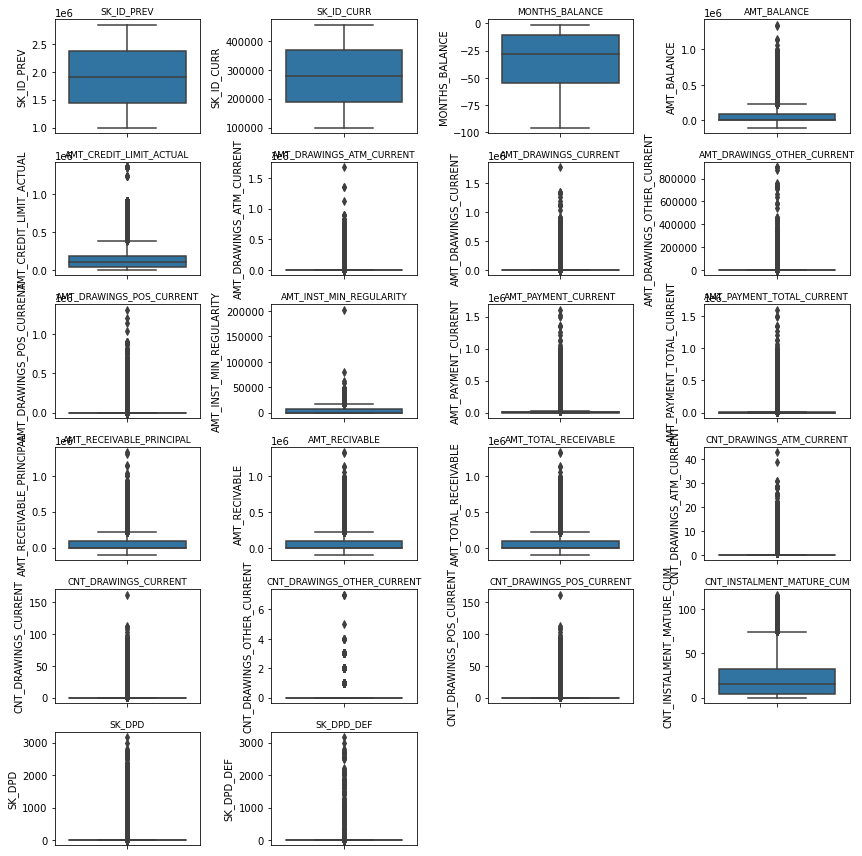

In [18]:
sample_fraction = 0.1 # Adjust as needed (start small)
seed = 42 # Optional for reproducibility
try:
    # Make sure the Spark DataFrame exists and is valid before sampling
    print(f"Original DataFrame row count: {credit_card_balance_df_num.count()}") # Add this check

    credit_card_balance_pandas_df_num = credit_card_balance_df_num.sample(
        withReplacement=False,
        fraction=sample_fraction,
        seed=seed
    ).toPandas()

    if credit_card_balance_pandas_df_num.empty:
         print(f"Warning: Sampled DataFrame is empty with fraction {sample_fraction}. Increase fraction or check original data.")
    else:
         print(f"Sampled DataFrame shape: {credit_card_balance_pandas_df_num.shape}")

         # --- Plotting Code ---
         num_plots_needed = len(credit_card_balance_pandas_df_num.columns)
         ncols = 4
         nrows = (num_plots_needed + ncols - 1) // ncols # Calculate rows needed

         fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, nrows * 2)) # Adjust figsize based on rows
         axes = axes.flatten() # Easier indexing

         for i, col in enumerate(credit_card_balance_pandas_df_num.columns):
             # Basic check if data looks numeric enough for boxplot
             if pd.api.types.is_numeric_dtype(credit_card_balance_pandas_df_num[col]):
                 sns.boxplot(data=credit_card_balance_pandas_df_num, y=col, ax=axes[i])
                 axes[i].set_title(col, fontsize=9)
             else:
                 print(f"Skipping non-numeric column: {col}")
                 axes[i].set_visible(False) # Hide axis for non-numeric

         # Hide any remaining unused axes
         for j in range(i + 1, len(axes)):
             axes[j].set_visible(False)

         plt.tight_layout()
         plt.show()

except Exception as e:
    print(f"An error occurred: {e}")
    # Add more specific error handling if needed based on potential Spark errors during count() or sample()

In [19]:
df_filtered_hist = merged_df.select('MONTHS_BALANCE','AMT_BALANCE','AMT_CREDIT_LIMIT_ACTUAL','AMT_DRAWINGS_ATM_CURRENT','AMT_DRAWINGS_CURRENT','AMT_DRAWINGS_OTHER_CURRENT','AMT_DRAWINGS_POS_CURRENT','AMT_INST_MIN_REGULARITY','AMT_PAYMENT_CURRENT','AMT_PAYMENT_TOTAL_CURRENT','AMT_RECEIVABLE_PRINCIPAL','AMT_RECIVABLE','AMT_TOTAL_RECEIVABLE','CNT_DRAWINGS_ATM_CURRENT','CNT_DRAWINGS_CURRENT','CNT_DRAWINGS_OTHER_CURRENT','CNT_DRAWINGS_POS_CURRENT','CNT_INSTALMENT_MATURE_CUM')

Sẽ lấy mẫu 10.0% dữ liệu cho các cột: ['MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM']
Đang thu thập dữ liệu mẫu về Driver Node dưới dạng Pandas DataFrame...
Đã thu thập thành công 322574 dòng dữ liệu mẫu.
Bắt đầu vẽ biểu đồ từ dữ liệu mẫu...


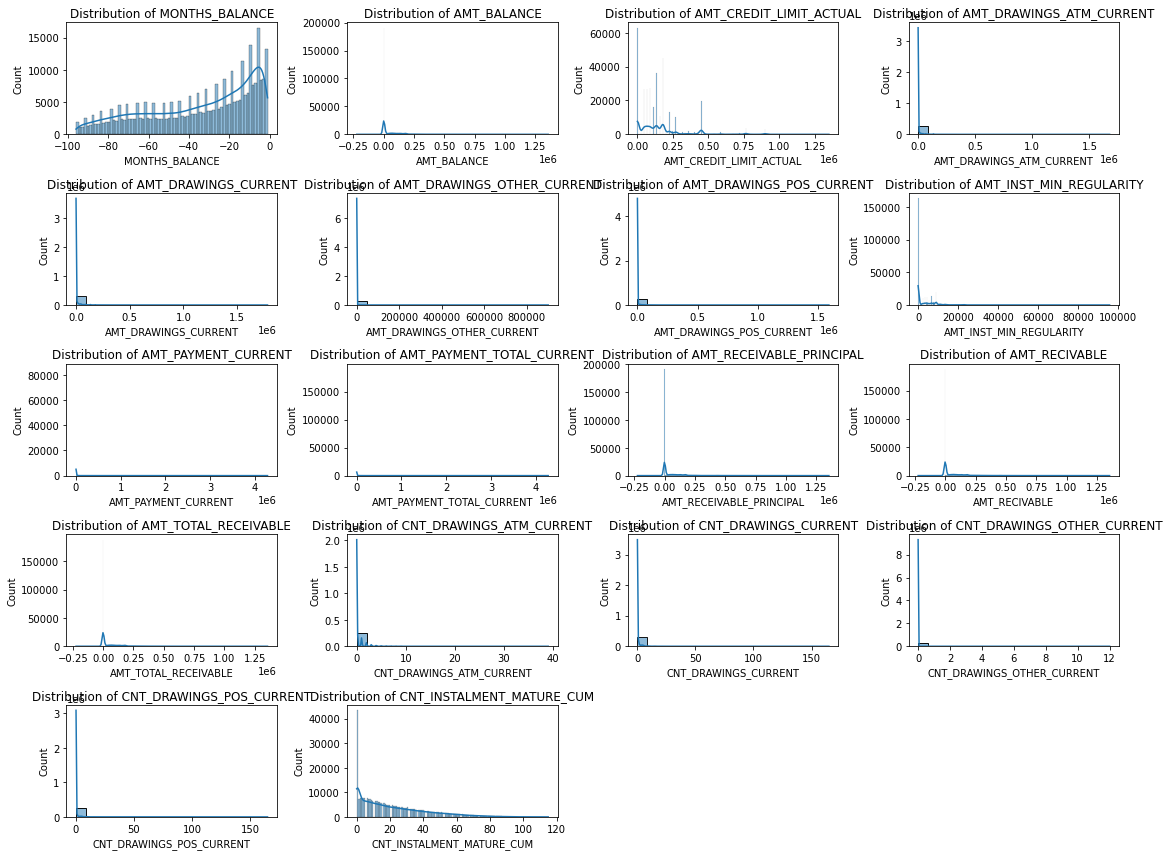

Hoàn thành vẽ biểu đồ từ mẫu.


In [20]:
columns_to_plot = [
    'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL',
    'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT',
    'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT',
    'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE',
    'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT',
    'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT',
    'CNT_INSTALMENT_MATURE_CUM'
]

sample_fraction = 0.1
seed = 42 # Sử dụng seed để đảm bảo kết quả lấy mẫu có thể lặp lại

# Kiểm tra xem các cột có tồn tại trong DataFrame không
existing_cols_in_df = [c for c in columns_to_plot if c in merged_df.columns]
missing_cols = [c for c in columns_to_plot if c not in merged_df.columns]

if missing_cols:
    print(f"Cảnh báo: Các cột sau không tồn tại trong Spark DataFrame và sẽ bị bỏ qua: {missing_cols}")

if not existing_cols_in_df:
    print("Lỗi: Không có cột nào được chỉ định tồn tại trong Spark DataFrame. Không thể tiếp tục.")
else:
    print(f"Sẽ lấy mẫu {sample_fraction*100}% dữ liệu cho các cột: {existing_cols_in_df}")

    # Chọn các cột tồn tại và thực hiện lấy mẫu trên Spark DataFrame
    sampled_spark_df = merged_df.select(existing_cols_in_df).sample(
        withReplacement=False, # Thường là False cho phân tích phân phối
        fraction=sample_fraction,
        seed=seed
    )

    # --- Bước 2: Thu thập mẫu về Driver Node ---
    print("Đang thu thập dữ liệu mẫu về Driver Node dưới dạng Pandas DataFrame...")
    try:
        # Sử dụng .toPandas() trên DataFrame mẫu (nhỏ hơn nhiều)
        sampled_pd_df = sampled_spark_df.toPandas()
        print(f"Đã thu thập thành công {len(sampled_pd_df)} dòng dữ liệu mẫu.")

        # --- Bước 3: Vẽ biểu đồ từ dữ liệu mẫu Pandas ---
        print("Bắt đầu vẽ biểu đồ từ dữ liệu mẫu...")
        plt.figure(figsize=(16, 12)) # Kích thước figure

        # Lặp qua danh sách cột ban đầu để giữ đúng thứ tự subplot
        for i, col in enumerate(columns_to_plot, 1):
            plt.subplot(5, 4, i) # Chọn vị trí subplot

            # Kiểm tra xem cột có trong DataFrame mẫu không (nó có thể đã bị thiếu từ đầu)
            if col in sampled_pd_df.columns:
                # Lấy dữ liệu cột từ Pandas DataFrame mẫu và bỏ qua NaN CHỈ cho việc vẽ
                plot_data = sampled_pd_df[col].dropna()

                if not plot_data.empty:
                    sns.histplot(plot_data, kde=True) # Vẽ histogram với KDE
                    plt.title(f'Distribution of {col}')
                    plt.xlabel(col)
                    plt.ylabel('Count') # Thêm nhãn trục y
                else:
                    # Trường hợp cột có trong mẫu nhưng toàn NaN hoặc rỗng sau dropna
                    plt.title(f'{col} (Không có dữ liệu hợp lệ trong mẫu)')
                    plt.xticks([])
                    plt.yticks([])
            else:
                # Trường hợp cột không có trong DataFrame gốc ban đầu
                 plt.title(f'{col} (Không tồn tại trong DF)')
                 plt.xticks([])
                 plt.yticks([])

        plt.tight_layout() # Tự động điều chỉnh layout
        plt.show() # Hiển thị biểu đồ
        print("Hoàn thành vẽ biểu đồ từ mẫu.")

    except Exception as e:
        print(f"Lỗi xảy ra trong quá trình thu thập mẫu hoặc vẽ biểu đồ: {e}")
        print("Hãy thử giảm giá trị 'sample_fraction' nếu đây là lỗi bộ nhớ.")

In [21]:
merged_df_subset = merged_df.filter(pyspark.sql.functions.col('TARGET') == 0)

merged_df_subset.show()

+----------+----------+--------------+-----------+-----------------------+------------------------+--------------------+--------------------------+------------------------+-----------------------+-------------------+-------------------------+------------------------+-------------+--------------------+------------------------+--------------------+--------------------------+------------------------+-------------------------+--------------------+------+----------+------+
|SK_ID_CURR|SK_ID_PREV|MONTHS_BALANCE|AMT_BALANCE|AMT_CREDIT_LIMIT_ACTUAL|AMT_DRAWINGS_ATM_CURRENT|AMT_DRAWINGS_CURRENT|AMT_DRAWINGS_OTHER_CURRENT|AMT_DRAWINGS_POS_CURRENT|AMT_INST_MIN_REGULARITY|AMT_PAYMENT_CURRENT|AMT_PAYMENT_TOTAL_CURRENT|AMT_RECEIVABLE_PRINCIPAL|AMT_RECIVABLE|AMT_TOTAL_RECEIVABLE|CNT_DRAWINGS_ATM_CURRENT|CNT_DRAWINGS_CURRENT|CNT_DRAWINGS_OTHER_CURRENT|CNT_DRAWINGS_POS_CURRENT|CNT_INSTALMENT_MATURE_CUM|NAME_CONTRACT_STATUS|SK_DPD|SK_DPD_DEF|TARGET|
+----------+----------+--------------+-----------+----

In [22]:
numeric_spark_types = (ByteType, ShortType, IntegerType, LongType, FloatType, DoubleType, DecimalType)

numeric_column_names = []
for field in merged_df.schema.fields:
    if isinstance(field.dataType, numeric_spark_types):
        numeric_column_names.append(field.name)

if not numeric_column_names:
    print("No numeric columns")
    merged_df_num = None 
else:
    merged_df_num = merged_df.select(*numeric_column_names)

    print(f"Numeric columns: {numeric_column_names}")
    merged_df_num.show(5)

Numeric columns: ['SK_ID_CURR', 'SK_ID_PREV', 'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM', 'SK_DPD', 'SK_DPD_DEF', 'TARGET']
+----------+----------+--------------+-----------+-----------------------+------------------------+--------------------+--------------------------+------------------------+-----------------------+-------------------+-------------------------+------------------------+-------------+--------------------+------------------------+--------------------+--------------------------+------------------------+-------------------------+------+----------+------+
|SK_ID_CURR

In [23]:
category_column_names = []
for field in merged_df.schema.fields:
    if isinstance(field.dataType, StringType):
        category_column_names.append(field.name)

if not category_column_names:
    print("No category columns")
    merged_df_cat = None # Hoặc gán là None
else:
    merged_df_cat = merged_df.select(*category_column_names)

    # 5. Hiển thị 5 dòng đầu của DataFrame mới (tương đương head())
    print(f"Category columns: {category_column_names}")
    merged_df_cat.show(5)

Category columns: ['NAME_CONTRACT_STATUS']
+--------------------+
|NAME_CONTRACT_STATUS|
+--------------------+
|              Active|
|              Active|
|              Active|
|              Active|
|              Active|
+--------------------+
only showing top 5 rows



In [24]:
null_check_exprs = [
    spark_sum(when(pyspark.sql.functions.col(c).isNull() | isnan(c), 1).otherwise(0)).alias(c)
    for c in merged_df.columns
]

null_counts_df = merged_df.agg(*null_check_exprs)

null_counts_df.show()

+----------+----------+--------------+-----------+-----------------------+------------------------+--------------------+--------------------------+------------------------+-----------------------+-------------------+-------------------------+------------------------+-------------+--------------------+------------------------+--------------------+--------------------------+------------------------+-------------------------+--------------------+------+----------+------+
|SK_ID_CURR|SK_ID_PREV|MONTHS_BALANCE|AMT_BALANCE|AMT_CREDIT_LIMIT_ACTUAL|AMT_DRAWINGS_ATM_CURRENT|AMT_DRAWINGS_CURRENT|AMT_DRAWINGS_OTHER_CURRENT|AMT_DRAWINGS_POS_CURRENT|AMT_INST_MIN_REGULARITY|AMT_PAYMENT_CURRENT|AMT_PAYMENT_TOTAL_CURRENT|AMT_RECEIVABLE_PRINCIPAL|AMT_RECIVABLE|AMT_TOTAL_RECEIVABLE|CNT_DRAWINGS_ATM_CURRENT|CNT_DRAWINGS_CURRENT|CNT_DRAWINGS_OTHER_CURRENT|CNT_DRAWINGS_POS_CURRENT|CNT_INSTALMENT_MATURE_CUM|NAME_CONTRACT_STATUS|SK_DPD|SK_DPD_DEF|TARGET|
+----------+----------+--------------+-----------+----

Có một số đặc trưng (feature) có lượng giá trị bị thiếu khá nhiều. Dưới đây là các cột đó:

- AMT_DRAWINGS_ATM_CURRENT: 605754

- AMT_DRAWINGS_OTHER_CURRENT: 605754

- AMT_DRAWINGS_POS_CURRENT: 605754

- AMT_INST_MIN_REGULARITY: 264384

- AMT_PAYMENT_CURRENT: 620093

- CNT_DRAWINGS_ATM_CURRENT: 605754

- CNT_DRAWINGS_OTHER_CURRENT: 605754

- CNT_DRAWINGS_POS_CURRENT: 605754

- CNT_INSTALMENT_MATURE_CUM: 264384

Việc xử lý giá trị bị thiếu được thực hiện bằng cách thay thế các giá trị thiếu bằng **median (trung vị)** của từng cột. Lý do sử dụng median là vì nó không bị ảnh hưởng bởi toàn bộ dữ liệu và ổn định trước các giá trị ngoại lai (outliers).

In [25]:
columns_to_fill_median = [
    'AMT_DRAWINGS_ATM_CURRENT',
    'AMT_DRAWINGS_OTHER_CURRENT',
    'AMT_DRAWINGS_POS_CURRENT',
    'AMT_INST_MIN_REGULARITY',
    'AMT_PAYMENT_CURRENT',
    'CNT_DRAWINGS_ATM_CURRENT',
    'CNT_DRAWINGS_OTHER_CURRENT',
    'CNT_DRAWINGS_POS_CURRENT',
    'CNT_INSTALMENT_MATURE_CUM'
]

existing_cols = [c for c in columns_to_fill_median if c in merged_df.columns]

if not existing_cols:
    print("Lỗi: Không có cột nào hợp lệ để thực hiện fillna.")
else:
    approx_median_exprs = [
        expr(f"percentile_approx({c}, 0.5)").alias(f"{c}_median")
        for c in existing_cols
    ]

    medians_df = merged_df.agg(*approx_median_exprs)
    medians_dict = medians_df.first().asDict()

    merged_df_filled = merged_df # Bắt đầu từ DataFrame gốc

    select_expressions = []
    for col_name in merged_df.columns:
        if col_name in existing_cols:
            median_value = medians_dict.get(f"{col_name}_median")

            if median_value is None:
                fill_value = 0.0 # Hoặc giá trị mặc định khác phù hợp với cột
            else:
                fill_value = median_value

            fill_expr = when(pyspark.sql.functions.col(col_name).isNull(), lit(fill_value)) \
                         .otherwise(pyspark.sql.functions.col(col_name)) \
                         .alias(col_name) # Giữ nguyên tên cột
            select_expressions.append(fill_expr)
        else:
            # Giữ nguyên các cột không cần fillna
            select_expressions.append(pyspark.sql.functions.col(col_name))

    merged_df_filled = merged_df.select(*select_expressions)

    # Gán lại biến spark_df nếu bạn muốn tiếp tục làm việc trên DataFrame đã fillna
    merged_df = merged_df_filled

In [26]:
null_check_exprs = [
    spark_sum(when(pyspark.sql.functions.col(c).isNull() | isnan(c), 1).otherwise(0)).alias(c)
    for c in merged_df.columns
]

null_counts_df = merged_df.agg(*null_check_exprs)

null_counts_df.show()

+----------+----------+--------------+-----------+-----------------------+------------------------+--------------------+--------------------------+------------------------+-----------------------+-------------------+-------------------------+------------------------+-------------+--------------------+------------------------+--------------------+--------------------------+------------------------+-------------------------+--------------------+------+----------+------+
|SK_ID_CURR|SK_ID_PREV|MONTHS_BALANCE|AMT_BALANCE|AMT_CREDIT_LIMIT_ACTUAL|AMT_DRAWINGS_ATM_CURRENT|AMT_DRAWINGS_CURRENT|AMT_DRAWINGS_OTHER_CURRENT|AMT_DRAWINGS_POS_CURRENT|AMT_INST_MIN_REGULARITY|AMT_PAYMENT_CURRENT|AMT_PAYMENT_TOTAL_CURRENT|AMT_RECEIVABLE_PRINCIPAL|AMT_RECIVABLE|AMT_TOTAL_RECEIVABLE|CNT_DRAWINGS_ATM_CURRENT|CNT_DRAWINGS_CURRENT|CNT_DRAWINGS_OTHER_CURRENT|CNT_DRAWINGS_POS_CURRENT|CNT_INSTALMENT_MATURE_CUM|NAME_CONTRACT_STATUS|SK_DPD|SK_DPD_DEF|TARGET|
+----------+----------+--------------+-----------+----

##### HANDLING OUTLIERS

In [27]:
from functools import reduce 

columns_to_check = [
    'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL',
    'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT',
    'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT',
    'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE',
    'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT',
    'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT',
    'CNT_INSTALMENT_MATURE_CUM', 'SK_DPD', 'SK_DPD_DEF'
]

existing_cols_to_check = [c for c in columns_to_check if c in merged_df.columns]

if not existing_cols_to_check:
    print("Lỗi: Không có cột nào hợp lệ để kiểm tra outlier.")
else:
    initial_count = merged_df.count()
    print(f'The number of rows before removing outliers: {initial_count}')

    filter_conditions = []

    relative_error = 0.00001 # Cân bằng giữa tốc độ và độ chính xác (0 = chính xác nhưng chậm)

    for col_name in existing_cols_to_check:
        try:
            quantiles = merged_df.approxQuantile(col_name, [0.25, 0.75], relative_error)
            if quantiles is None or len(quantiles) < 2 or quantiles[0] is None or quantiles[1] is None:
                 print(f"    Cảnh báo: Không thể tính toán quantiles hợp lệ cho cột {col_name}. Bỏ qua cột này.")
                 continue # Chuyển sang cột tiếp theo

            Q1 = quantiles[0]
            Q3 = quantiles[1]

            # Tính IQR và các giới hạn
            IQR = Q3 - Q1
            low_limit = Q1 - (IQR * 1.5)
            high_limit = Q3 + (IQR * 1.5)

            print(f"    Giới hạn cho {col_name}: [{low_limit}, {high_limit}] (Q1={Q1}, Q3={Q3}, IQR={IQR})")

            condition = (pyspark.sql.functions.col(col_name) >= low_limit) & (pyspark.sql.functions.col(col_name) <= high_limit)

            filter_conditions.append(condition)

        except Exception as e:
             print(f"    Lỗi khi xử lý cột {col_name}: {e}. Bỏ qua cột này.")


    if filter_conditions:
        combined_filter = reduce(lambda a, b: a & b, filter_conditions)
        filtered_merged_df = merged_df.filter(combined_filter)

        # In số lượng hàng sau khi lọc (tốn tài nguyên)
        final_count = filtered_merged_df.count()
        print(f'The number of rows after removing outliers: {final_count}')

        # Gán DataFrame đã lọc lại cho biến ban đầu (nếu muốn)
        merged_df = filtered_merged_df
    else:
        print("\nKhông có điều kiện lọc nào được tạo ra. DataFrame không thay đổi.")
        print(f'Số lượng hàng không đổi: {initial_count}')

The number of rows before removing outliers: 3227965
    Giới hạn cho MONTHS_BALANCE: [-123.5, 56.5] (Q1=-56.0, Q3=-11.0, IQR=45.0)
    Giới hạn cho AMT_BALANCE: [-135609.255, 226015.425] (Q1=0.0, Q3=90406.17, IQR=90406.17)
    Giới hạn cho AMT_CREDIT_LIMIT_ACTUAL: [-157500.0, 382500.0] (Q1=45000.0, Q3=180000.0, IQR=135000.0)
    Giới hạn cho AMT_DRAWINGS_ATM_CURRENT: [0.0, 0.0] (Q1=0.0, Q3=0.0, IQR=0.0)
    Giới hạn cho AMT_DRAWINGS_CURRENT: [0.0, 0.0] (Q1=0.0, Q3=0.0, IQR=0.0)
    Giới hạn cho AMT_DRAWINGS_OTHER_CURRENT: [0.0, 0.0] (Q1=0.0, Q3=0.0, IQR=0.0)
    Giới hạn cho AMT_DRAWINGS_POS_CURRENT: [0.0, 0.0] (Q1=0.0, Q3=0.0, IQR=0.0)
    Giới hạn cho AMT_INST_MIN_REGULARITY: [-8437.5, 14062.5] (Q1=0.0, Q3=5625.0, IQR=5625.0)
    Giới hạn cho AMT_PAYMENT_CURRENT: [-11529.675000000001, 19877.805] (Q1=248.13, Q3=8100.0, IQR=7851.87)
    Giới hạn cho AMT_PAYMENT_TOTAL_CURRENT: [-10125.0, 16875.0] (Q1=0.0, Q3=6750.0, IQR=6750.0)
    Giới hạn cho AMT_RECEIVABLE_PRINCIPAL: [-129962.610000

##### HANDLING DUPLICATE DATA

In [28]:
from pyspark.sql import DataFrame

def check_duplicates_spark(spark_df: DataFrame):
    if not isinstance(spark_df, DataFrame):
        return

    if not spark_df.columns:
         return
        
    all_columns = spark_df.columns

    df_counts = spark_df.groupBy(all_columns).count().alias("counts")

    duplicate_rows_df = df_counts.filter(pyspark.sql.functions.col("count") > 1)

    duplicate_rows_df.cache()

    num_duplicate_types = duplicate_rows_df.count()

    if num_duplicate_types > 0:
        try:
            total_duplicate_rows = duplicate_rows_df.select(F.sum(F.col("count") - 1)).first()[0]
            print(f"Tìm thấy tổng cộng {total_duplicate_rows} hàng dữ liệu bị trùng lặp (không bao gồm bản gốc).")
            print(f"Có {num_duplicate_types} loại hàng khác nhau bị trùng lặp.")
            print("\nHiển thị một số loại hàng bị trùng lặp và số lần xuất hiện:")
            duplicate_rows_df.show(truncate=False)
        except Exception as e:
            print(f"Lỗi khi tính toán hoặc hiển thị dữ liệu trùng lặp: {e}")

    else:
        print("No duplicate data.")

    # Giải phóng bộ nhớ cache
    duplicate_rows_df.unpersist()

In [29]:
check_duplicates_spark(merged_df)

No duplicate data.


##### FEATURE ENGINEERING

Feature Engineering is necessary to increase the complexity of data so that the best performance results can be obtained during modeling. The actions taken include adding new features from the existing features. Here are the features that need to be added: 

**Payment to Balance Ratio**: The ratio of payments to the existing balance, which indicates how well the borrower manages their debt. For example: `AMT_PAYMENT_TOTAL_CURRENT / AMT_BALANCE`. 

**Utilization Rate**: The ratio of the amount of credit used to the credit limit. For example: 
`AMT_BALANCE / AMT_CREDIT_LIMIT_ACTUAL`. 

**Regularization**: The ratio of the amount that must be paid to the amount of installments or minimum installments paid periodically over a certain period. For example: `AMT_PAYMENT_CURRENT / AMT_INST_MIN_REGULARITY`.

In [30]:
merged_df = merged_df.withColumn(
    'UTILIZATION_RATE',
    pyspark.sql.functions.col('AMT_BALANCE') / pyspark.sql.functions.col('AMT_CREDIT_LIMIT_ACTUAL')
).withColumn(
    'PAYMENT_TO_BALANCE_RATIO',
    pyspark.sql.functions.col('AMT_PAYMENT_TOTAL_CURRENT') / pyspark.sql.functions.col('AMT_BALANCE')
).withColumn(
    'Regularization',
    pyspark.sql.functions.col('AMT_PAYMENT_CURRENT') / pyspark.sql.functions.col('AMT_INST_MIN_REGULARITY')
)

In [31]:
columns_to_ensure_numeric = [
    'UTILIZATION_RATE',
    'PAYMENT_TO_BALANCE_RATIO',
    'Regularization'
]

# Tạo DataFrame mới để tránh thay đổi DataFrame gốc trong vòng lặp
spark_df_numeric = merged_df

# Lặp qua từng cột và áp dụng .cast()
for col_name in columns_to_ensure_numeric:
    # Kiểm tra xem cột có tồn tại không trước khi cast
    if col_name in spark_df_numeric.columns:
        spark_df_numeric = spark_df_numeric.withColumn(
            col_name,
            pyspark.sql.functions.col(col_name).cast(DoubleType())
        )
    else:
        print(f"  Cảnh báo: Cột '{col_name}' không tồn tại để ép kiểu.")


# In schema để xác nhận kiểu dữ liệu đã thay đổi (hoặc vẫn là DoubleType)
spark_df_numeric.printSchema()

# Gán lại vào biến ban đầu nếu muốn
merged_df = spark_df_numeric

root
 |-- SK_ID_CURR: integer (nullable = true)
 |-- SK_ID_PREV: integer (nullable = true)
 |-- MONTHS_BALANCE: integer (nullable = true)
 |-- AMT_BALANCE: double (nullable = true)
 |-- AMT_CREDIT_LIMIT_ACTUAL: integer (nullable = true)
 |-- AMT_DRAWINGS_ATM_CURRENT: double (nullable = true)
 |-- AMT_DRAWINGS_CURRENT: double (nullable = true)
 |-- AMT_DRAWINGS_OTHER_CURRENT: double (nullable = true)
 |-- AMT_DRAWINGS_POS_CURRENT: double (nullable = true)
 |-- AMT_INST_MIN_REGULARITY: double (nullable = true)
 |-- AMT_PAYMENT_CURRENT: double (nullable = true)
 |-- AMT_PAYMENT_TOTAL_CURRENT: double (nullable = true)
 |-- AMT_RECEIVABLE_PRINCIPAL: double (nullable = true)
 |-- AMT_RECIVABLE: double (nullable = true)
 |-- AMT_TOTAL_RECEIVABLE: double (nullable = true)
 |-- CNT_DRAWINGS_ATM_CURRENT: double (nullable = true)
 |-- CNT_DRAWINGS_CURRENT: integer (nullable = true)
 |-- CNT_DRAWINGS_OTHER_CURRENT: double (nullable = true)
 |-- CNT_DRAWINGS_POS_CURRENT: double (nullable = true)
 |

In [32]:
numeric_spark_types = (ByteType, ShortType, IntegerType, LongType, FloatType, DoubleType, DecimalType)

numeric_column_names = []
for field in merged_df.schema.fields:
    if isinstance(field.dataType, numeric_spark_types):
        numeric_column_names.append(field.name)

if not numeric_column_names:
    print("No numeric columns")
    merged_df_num = None 
else:
    merged_df_num = merged_df.select(*numeric_column_names)

    print(f"Numeric columns: {numeric_column_names}")
    merged_df_num.show(5)

Numeric columns: ['SK_ID_CURR', 'SK_ID_PREV', 'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM', 'SK_DPD', 'SK_DPD_DEF', 'TARGET', 'UTILIZATION_RATE', 'PAYMENT_TO_BALANCE_RATIO', 'Regularization']
+----------+----------+--------------+-----------+-----------------------+------------------------+--------------------+--------------------------+------------------------+-----------------------+-------------------+-------------------------+------------------------+-------------+--------------------+------------------------+--------------------+--------------------------+----------------------

Due to the `Month_Balance` feature experiencing right skewness, it is necessary to transform the data distribution to be more normal. This is required because it will affect the performance of the learning model.

##### LOG TRANSFORMATION 

In [33]:
merged_df = merged_df.withColumn(
        'MONTHS_BALANCE',
        pyspark.sql.functions.log(pyspark.sql.functions.col('MONTHS_BALANCE') + 1)
    )

In the `MONTHS_BALANCE` column, there is skewness, which can lead to a decrease in model accuracy. Therefore, a log transformation needs to be performed so that the data is symmetrically distributed and also to reduce the impact of extreme values on the model, making it more robust against undesirable variations. It can be seen from the scatter plot of the `MONTHS_BALANCE` data that it is already normally distributed using the log transformation technique.

##### ONE HOT ENCODING

In [34]:
distinct_values_df = merged_df.select('NAME_CONTRACT_STATUS').distinct()
try:
        collected_rows = distinct_values_df.collect() # List[Row]
        
        unique_values_list = [row['NAME_CONTRACT_STATUS'] for row in collected_rows]

        import numpy as np # Sử dụng numpy nếu muốn output giống array
        unique_values_array = np.array(unique_values_list)
        print(unique_values_array)
except Exception as e:
        print(f"Lỗi xảy ra trong quá trình lấy hoặc thu thập giá trị duy nhất: {e}")
        print("Xem xét lại kích thước dữ liệu và bộ nhớ driver nếu lỗi liên quan đến bộ nhớ.")

['Demand' 'Approved' 'Completed' 'Active' 'Signed' 'Sent proposal'
 'Refused']


In [35]:
import re

try:
        unique_values = [row['NAME_CONTRACT_STATUS'] for row in merged_df.select('NAME_CONTRACT_STATUS').distinct().collect()]

        spark_df_encoded_manual = merged_df

        for category in unique_values:
            safe_category_name = re.sub(r'\W+', '_', str(category).strip())
            new_col_name = f"NAME_CONTRACT_STATUS_{safe_category_name}"

            spark_df_encoded_manual = spark_df_encoded_manual.withColumn(
                new_col_name,
                when(pyspark.sql.functions.col('NAME_CONTRACT_STATUS') == category, 1).otherwise(0)
            )

        spark_df_encoded_manual = spark_df_encoded_manual.drop('NAME_CONTRACT_STATUS')

        spark_df_encoded_manual.printSchema()

        merged_df = spark_df_encoded_manual

except Exception as e:
        print(f"Lỗi trong quá trình lấy giá trị duy nhất hoặc tạo cột: {e}")

root
 |-- SK_ID_CURR: integer (nullable = true)
 |-- SK_ID_PREV: integer (nullable = true)
 |-- MONTHS_BALANCE: double (nullable = true)
 |-- AMT_BALANCE: double (nullable = true)
 |-- AMT_CREDIT_LIMIT_ACTUAL: integer (nullable = true)
 |-- AMT_DRAWINGS_ATM_CURRENT: double (nullable = true)
 |-- AMT_DRAWINGS_CURRENT: double (nullable = true)
 |-- AMT_DRAWINGS_OTHER_CURRENT: double (nullable = true)
 |-- AMT_DRAWINGS_POS_CURRENT: double (nullable = true)
 |-- AMT_INST_MIN_REGULARITY: double (nullable = true)
 |-- AMT_PAYMENT_CURRENT: double (nullable = true)
 |-- AMT_PAYMENT_TOTAL_CURRENT: double (nullable = true)
 |-- AMT_RECEIVABLE_PRINCIPAL: double (nullable = true)
 |-- AMT_RECIVABLE: double (nullable = true)
 |-- AMT_TOTAL_RECEIVABLE: double (nullable = true)
 |-- CNT_DRAWINGS_ATM_CURRENT: double (nullable = true)
 |-- CNT_DRAWINGS_CURRENT: integer (nullable = true)
 |-- CNT_DRAWINGS_OTHER_CURRENT: double (nullable = true)
 |-- CNT_DRAWINGS_POS_CURRENT: double (nullable = true)
 |-

Since there are categorical variables, one hot encoding needs to be performed. This aims to enable interpretation within machine learning algorithms, such as linear regression, logistic regression, and distance-based algorithms (like k-NN) which cannot handle categorical variables directly. One-hot encoding transforms categorical variables into a numerical format so that they can be used in these models.

In [36]:
bool_columns = [
    'NAME_CONTRACT_STATUS_Active', 'NAME_CONTRACT_STATUS_Approved',
    'NAME_CONTRACT_STATUS_Completed', 'NAME_CONTRACT_STATUS_Demand',
    'NAME_CONTRACT_STATUS_Refused', 'NAME_CONTRACT_STATUS_Sent_proposal', # Lưu ý _ thay vì khoảng trắng
    'NAME_CONTRACT_STATUS_Signed'
]

spark_df_casted = merged_df

for col_name in bool_columns:
    if col_name in spark_df_casted.columns:
        spark_df_casted = spark_df_casted.withColumn(
            col_name,
            pyspark.sql.functions.col(col_name).cast(IntegerType())
        )
        # print(f"  Đã ép kiểu cột '{col_name}' sang IntegerType.") # Bỏ comment nếu muốn xem log chi tiết
    else:
        print(f"  Cảnh báo: Cột '{col_name}' không tồn tại trong DataFrame. Bỏ qua.")

# In schema để xác nhận kiểu dữ liệu đã thay đổi
spark_df_casted.printSchema() # level=1 chỉ hiển thị tên cột và kiểu dữ liệu

# Gán lại vào biến ban đầu nếu muốn
merged_df = spark_df_casted

root
 |-- SK_ID_CURR: integer (nullable = true)
 |-- SK_ID_PREV: integer (nullable = true)
 |-- MONTHS_BALANCE: double (nullable = true)
 |-- AMT_BALANCE: double (nullable = true)
 |-- AMT_CREDIT_LIMIT_ACTUAL: integer (nullable = true)
 |-- AMT_DRAWINGS_ATM_CURRENT: double (nullable = true)
 |-- AMT_DRAWINGS_CURRENT: double (nullable = true)
 |-- AMT_DRAWINGS_OTHER_CURRENT: double (nullable = true)
 |-- AMT_DRAWINGS_POS_CURRENT: double (nullable = true)
 |-- AMT_INST_MIN_REGULARITY: double (nullable = true)
 |-- AMT_PAYMENT_CURRENT: double (nullable = true)
 |-- AMT_PAYMENT_TOTAL_CURRENT: double (nullable = true)
 |-- AMT_RECEIVABLE_PRINCIPAL: double (nullable = true)
 |-- AMT_RECIVABLE: double (nullable = true)
 |-- AMT_TOTAL_RECEIVABLE: double (nullable = true)
 |-- CNT_DRAWINGS_ATM_CURRENT: double (nullable = true)
 |-- CNT_DRAWINGS_CURRENT: integer (nullable = true)
 |-- CNT_DRAWINGS_OTHER_CURRENT: double (nullable = true)
 |-- CNT_DRAWINGS_POS_CURRENT: double (nullable = true)
 |-

In [37]:
null_check_exprs = [
    spark_sum(when(pyspark.sql.functions.col(c).isNull() | isnan(c), 1).otherwise(0)).alias(c)
    for c in merged_df.columns
]

null_counts_df = merged_df.agg(*null_check_exprs)

null_counts_df.show()

+----------+----------+--------------+-----------+-----------------------+------------------------+--------------------+--------------------------+------------------------+-----------------------+-------------------+-------------------------+------------------------+-------------+--------------------+------------------------+--------------------+--------------------------+------------------------+-------------------------+------+----------+------+----------------+------------------------+--------------+---------------------------+-----------------------------+------------------------------+---------------------------+---------------------------+----------------------------------+----------------------------+
|SK_ID_CURR|SK_ID_PREV|MONTHS_BALANCE|AMT_BALANCE|AMT_CREDIT_LIMIT_ACTUAL|AMT_DRAWINGS_ATM_CURRENT|AMT_DRAWINGS_CURRENT|AMT_DRAWINGS_OTHER_CURRENT|AMT_DRAWINGS_POS_CURRENT|AMT_INST_MIN_REGULARITY|AMT_PAYMENT_CURRENT|AMT_PAYMENT_TOTAL_CURRENT|AMT_RECEIVABLE_PRINCIPAL|AMT_RECIVABLE|A

In [38]:
columns_to_fill_median = [
    'MONTHS_BALANCE', 
    'UTILIZATION_RATE',
    'PAYMENT_TO_BALANCE_RATIO',
    'Regularization'
]

existing_cols = [c for c in columns_to_fill_median if c in merged_df.columns]

if not existing_cols:
    print("Lỗi: Không có cột nào hợp lệ để thực hiện fillna.")
else:
    approx_median_exprs = [
        expr(f"percentile_approx({c}, 0.5)").alias(f"{c}_median")
        for c in existing_cols
    ]

    medians_df = merged_df.agg(*approx_median_exprs)
    medians_dict = medians_df.first().asDict()

    merged_df_filled = merged_df # Bắt đầu từ DataFrame gốc

    select_expressions = []
    for col_name in merged_df.columns:
        if col_name in existing_cols:
            median_value = medians_dict.get(f"{col_name}_median")

            if median_value is None:
                fill_value = 0.0 # Hoặc giá trị mặc định khác phù hợp với cột
            else:
                fill_value = median_value

            fill_expr = when(pyspark.sql.functions.col(col_name).isNull(), lit(fill_value)) \
                         .otherwise(pyspark.sql.functions.col(col_name)) \
                         .alias(col_name) # Giữ nguyên tên cột
            select_expressions.append(fill_expr)
        else:
            # Giữ nguyên các cột không cần fillna
            select_expressions.append(pyspark.sql.functions.col(col_name))

    merged_df_filled = merged_df.select(*select_expressions)

    # Gán lại biến spark_df nếu bạn muốn tiếp tục làm việc trên DataFrame đã fillna
    merged_df = merged_df_filled

In [39]:
null_check_exprs = [
    spark_sum(when(pyspark.sql.functions.col(c).isNull() | isnan(c), 1).otherwise(0)).alias(c)
    for c in merged_df.columns
]

null_counts_df = merged_df.agg(*null_check_exprs)

null_counts_df.show()

+----------+----------+--------------+-----------+-----------------------+------------------------+--------------------+--------------------------+------------------------+-----------------------+-------------------+-------------------------+------------------------+-------------+--------------------+------------------------+--------------------+--------------------------+------------------------+-------------------------+------+----------+------+----------------+------------------------+--------------+---------------------------+-----------------------------+------------------------------+---------------------------+---------------------------+----------------------------------+----------------------------+
|SK_ID_CURR|SK_ID_PREV|MONTHS_BALANCE|AMT_BALANCE|AMT_CREDIT_LIMIT_ACTUAL|AMT_DRAWINGS_ATM_CURRENT|AMT_DRAWINGS_CURRENT|AMT_DRAWINGS_OTHER_CURRENT|AMT_DRAWINGS_POS_CURRENT|AMT_INST_MIN_REGULARITY|AMT_PAYMENT_CURRENT|AMT_PAYMENT_TOTAL_CURRENT|AMT_RECEIVABLE_PRINCIPAL|AMT_RECIVABLE|A

In [40]:
column_name = 'TARGET'

if column_name not in merged_df.columns:
    print(f"Lỗi: Cột '{column_name}' không tồn tại trong DataFrame.")
else:
    total_count_col = merged_df.filter(pyspark.sql.functions.col(column_name).isNotNull()).count()

    if total_count_col == 0:
        print(f"Cột '{column_name}' không có giá trị hợp lệ (toàn null hoặc rỗng). Không thể tính tỷ lệ.")
    else:
        value_counts_df = merged_df.groupBy(column_name).count()

        proportions_df = value_counts_df.withColumn(
            'proportion',
             pyspark.sql.functions.col('count') / total_count_col
        )

        proportions_df_sorted = proportions_df.orderBy(pyspark.sql.functions.desc('proportion'))

        proportions_df_sorted.show()

+------+-------+-------------------+
|TARGET|  count|         proportion|
+------+-------+-------------------+
|     0|2068910| 0.9344818007511411|
|     1| 145055|0.06551819924885895|
+------+-------+-------------------+



It can be seen that the data distribution is very imbalanced. Where Target 0 has a large amount of data around 93% while Target 1 only has 0.06 out of the many data.

In [41]:
df_to_check = merged_df

float_double_cols = [
    f.name for f in df_to_check.schema.fields
    if isinstance(f.dataType, (FloatType, DoubleType))
]

if not float_double_cols:
    print("Không tìm thấy cột kiểu FloatType hoặc DoubleType nào để kiểm tra inf/NaN.")
else:
    agg_expressions = []
    for col_name in float_double_cols:
        is_infinity_condition = (
            (pyspark.sql.functions.col(col_name) == lit(float('inf'))) |
            (pyspark.sql.functions.col(col_name) == lit(float('-inf')))
        )
        agg_expressions.append(
            spark_sum(is_infinity_condition.cast("long")).alias(f"{col_name}_inf_count")
        )
        agg_expressions.append(
            spark_sum(isnan(pyspark.sql.functions.col(col_name)).cast("long")).alias(f"{col_name}_nan_count")
        )

    if agg_expressions: # Chỉ thực hiện nếu có biểu thức để tính
        counts_result_df = df_to_check.agg(*agg_expressions)

        result_row = counts_result_df.collect()[0] # Kết quả agg chỉ có 1 hàng

        # 5. Cộng tổng các số đếm từ các cột khác nhau
        total_inf_count = 0
        total_nan_count = 0
        for col_name in float_double_cols:
            inf_count = result_row[f"{col_name}_inf_count"]
            nan_count = result_row[f"{col_name}_nan_count"]
            if inf_count is not None:
                total_inf_count += inf_count
            if nan_count is not None:
                total_nan_count += nan_count

        # 6. In kết quả giống định dạng gốc
        print(f"{total_inf_count} inf values found in checked columns")
        print(f"{total_nan_count} NaN values found in checked columns")
    else:
        print("Không có biểu thức aggregation nào được tạo.")

0 inf values found in checked columns
0 NaN values found in checked columns


##### REMOVAL OF SEVERAL COLUMNS

In [42]:
columns_to_drop = [
    'AMT_RECIVABLE', 'AMT_RECEIVABLE_PRINCIPAL', 'CNT_INSTALMENT_MATURE_CUM',
    'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT'
]

df_dropped = merged_df.drop(*columns_to_drop)

##### EXPORT DATAFRAME TO EXTERNAL

In [126]:
# from pyspark.sql import SparkSession
# import os
# import glob
# import shutil
# from google.colab import drive # Import thư viện drive của Colab

# # Giả sử bạn đã có SparkSession tên là 'spark'
# # spark = SparkSession.builder.appName("SaveSingleCsvToDrive").getOrCreate()

# # Giả sử 'spark_df' là DataFrame PySpark cuối cùng của bạn
# # spark_df = ...

# # --- BẮT ĐẦU PHẦN CODE GHI LÊN GOOGLE DRIVE ---

# # 1. Mount Google Drive vào Colab
# try:
#     print("Đang mount Google Drive...")
#     drive.mount('/content/drive')
#     print("Google Drive đã được mount thành công tại /content/drive")
# except Exception as e:
#     print(f"Lỗi khi mount Google Drive: {e}")
#     print("Vui lòng kiểm tra lại quá trình xác thực.")
#     # Có thể dừng script ở đây nếu mount lỗi: raise e

# # --- Các thông số ---
# # Đường dẫn file CSV cuối cùng bạn mong muốn TRÊN GOOGLE DRIVE
# # Thay đổi '/My Drive/' nếu bạn muốn lưu vào thư mục khác trong Drive
# final_drive_path = '/content/drive/My Drive/Credit_Card_Balance_Preprocessing.csv'

# # Đường dẫn đến thư mục tạm TRÊN HỆ THỐNG FILE CỦA COLAB
# # Spark sẽ ghi vào đây trước khi di chuyển sang Drive
# temp_colab_dir = '/content/temp_spark_csv_output'

# print("\nBắt đầu quá trình ghi CSV lên Google Drive...")
# print(f"Sử dụng thư mục tạm trên Colab: {temp_colab_dir}")
# print(f"File đích cuối cùng trên Drive: {final_drive_path}")

# try:
#     # Đảm bảo thư mục tạm không tồn tại từ lần chạy trước (an toàn hơn)
#     if os.path.exists(temp_colab_dir):
#          print(f"  Xóa thư mục tạm cũ: {temp_colab_dir}")
#          shutil.rmtree(temp_colab_dir)

#     # 2. Coalesce thành 1 partition và ghi vào thư mục tạm trên Colab
#     print(f"  Spark đang ghi vào thư mục tạm Colab: {temp_colab_dir}")
#     spark_df.coalesce(1).write \
#         .mode("overwrite") \
#         .option("header", "true") \
#         .csv(temp_colab_dir) # <<< GHI VÀO COLAB TEMP DIR

#     print("  Spark đã ghi xong vào thư mục tạm Colab.")

#     # 3. Tìm file part-*.csv duy nhất trong thư mục tạm Colab
#     part_files = glob.glob(os.path.join(temp_colab_dir, "part-*.csv"))

#     if not part_files:
#         raise RuntimeError(f"Không tìm thấy file part-*.csv nào trong {temp_colab_dir}.")
#     if len(part_files) > 1:
#         print(f"Cảnh báo: Tìm thấy nhiều hơn 1 file part trong {temp_colab_dir}. Sử dụng file đầu tiên: {part_files[0]}")

#     source_csv_file = part_files[0]
#     print(f"  Đã tìm thấy file nguồn: {source_csv_file}")

#     # 4. Di chuyển file nguồn từ Colab sang Google Drive
#     print(f"  Đang di chuyển file sang Google Drive: {final_drive_path}")
#     # Sử dụng shutil.move để di chuyển file
#     shutil.move(source_csv_file, final_drive_path) # <<< DI CHUYỂN SANG DRIVE

#     # 5. Xóa thư mục tạm trên Colab
#     print(f"  Đang xóa thư mục tạm Colab: {temp_colab_dir}")
#     shutil.rmtree(temp_colab_dir)

#     print("-" * 30)
#     print(f"Đã lưu thành công file CSV duy nhất trên Google Drive tại:")
#     print(final_drive_path)
#     print("-" * 30)

# except Exception as e:
#     print(f"\nĐã xảy ra lỗi trong quá trình ghi hoặc xử lý file:")
#     print(e)
#     print(f"Kiểm tra lại quyền ghi, dung lượng Google Drive và nội dung thư mục tạm (nếu còn): {temp_colab_dir}")

# # --- KẾT THÚC PHẦN CODE GHI LÊN GOOGLE DRIVE ---

In [66]:
def featureInfo(spark_df: DataFrame):
    total_rows = spark_df.count()
    print(f"Total rows: {total_rows}")

    if total_rows == 0:
        kolom = ["feature", "data_type", "null_sum", "null_persen", "count_non_null", "count_unique_approx", "sample"]
        return pd.DataFrame(columns=kolom)

    agg_expressions = []
    for col_name in spark_df.columns:
        agg_expressions.append(
            spark_sum(pyspark.sql.functions.col(col_name).isNull().cast("long")).alias(f"{col_name}_null_count")
        )

        agg_expressions.append(
            pyspark.sql.functions.countDistinct(pyspark.sql.functions.col(col_name)).alias(f"{col_name}_approx_nunique")
        )

    agg_results_row = spark_df.agg(*agg_expressions).first()

    try:
        dup_counts = spark_df.groupBy(spark_df.columns).count().filter(pyspark.sql.functions.col("count") > 1)
        total_duplicate_rows_df = dup_counts.select(spark_sum(pyspark.sql.functions.col("count") - 1).alias("total_duplicates"))
        total_duplicate_rows_result = total_duplicate_rows_df.first()
        total_duplicate_rows = total_duplicate_rows_result["total_duplicates"] if total_duplicate_rows_result and total_duplicate_rows_result["total_duplicates"] is not None else 0
    except Exception as e:
         total_duplicate_rows = "Error"

    summary_rows = []
    col_dtypes = spark_df.dtypes

    for i, (col_name, dtype_str) in enumerate(col_dtypes):
        print(f"    Processing column: {col_name} ({i+1}/{len(col_dtypes)})")
        try:
            null_count = agg_results_row[f"{col_name}_null_count"]
            null_count = null_count if null_count is not None else total_rows

            approx_nunique = agg_results_row[f"{col_name}_approx_nunique"]
            approx_nunique = approx_nunique if approx_nunique is not None else 0

            null_percent = (null_count / total_rows) * 100 if total_rows > 0 else 0
            count_non_null = total_rows - null_count

            sample_rows = spark_df.select(col_name).distinct().limit(4).collect()
            sample_values = [row[col_name] for row in sample_rows if row is not None]

            summary_rows.append([
                col_name,
                dtype_str,        # Kiểu dữ liệu dạng chuỗi từ .dtypes
                null_count,
                null_percent,
                count_non_null,   # Tương đương với data[i].count() của Pandas
                approx_nunique,   # Số lượng unique xấp xỉ
                sample_values     # List các mẫu giá trị duy nhất
            ])
        except Exception as e:
             print(f"    Lỗi khi xử lý cột {col_name}: {e}. Thêm hàng lỗi vào bảng tóm tắt.")
             summary_rows.append([
                 col_name, dtype_str, 'Error', 'Error', 'Error', 'Error', ['Error']
             ])


    # --- 4. Tạo Pandas DataFrame kết quả ---
    columns = ["feature", "data_type", "null_sum", "null_persen", "count_non_null", "count_unique_approx", "sample"]
    df = pd.DataFrame(data=summary_rows, columns=columns)

    print("Hoàn thành thu thập thông tin feature.")
    return df

#### `Installment Payments_DF`

In [67]:
ip = featureInfo(installments_payments_df)

Total rows: 13605401
    Processing column: SK_ID_PREV (1/8)
    Processing column: SK_ID_CURR (2/8)
    Processing column: NUM_INSTALMENT_VERSION (3/8)
    Processing column: NUM_INSTALMENT_NUMBER (4/8)
    Processing column: DAYS_INSTALMENT (5/8)
    Processing column: DAYS_ENTRY_PAYMENT (6/8)
    Processing column: AMT_INSTALMENT (7/8)
    Processing column: AMT_PAYMENT (8/8)
Hoàn thành thu thập thông tin feature.


Inner join because the remaining IDs that do not exist are data from the application test.

In [68]:
application_train_df_selected = application_train_df.select('SK_ID_CURR', 'TARGET')

In [105]:
ip_target = installments_payments_df.join(application_train_df_selected, on='SK_ID_CURR', how='inner')

In [106]:
ip_target.show(10)

+----------+----------+----------------------+---------------------+---------------+------------------+--------------+-----------+------+
|SK_ID_CURR|SK_ID_PREV|NUM_INSTALMENT_VERSION|NUM_INSTALMENT_NUMBER|DAYS_INSTALMENT|DAYS_ENTRY_PAYMENT|AMT_INSTALMENT|AMT_PAYMENT|TARGET|
+----------+----------+----------------------+---------------------+---------------+------------------+--------------+-----------+------+
|    161674|   1054186|                   1.0|                    6|        -1180.0|           -1187.0|       6948.36|    6948.36|     0|
|    151639|   1330831|                   0.0|                   34|        -2156.0|           -2156.0|      1716.525|   1716.525|     0|
|    193053|   2085231|                   2.0|                    1|          -63.0|             -63.0|       25425.0|    25425.0|     0|
|    199697|   2452527|                   1.0|                    3|        -2418.0|           -2426.0|      24350.13|   24350.13|     0|
|    167756|   2714724|           

In [107]:
featureInfo(ip_target)

Total rows: 11591592
    Processing column: SK_ID_CURR (1/9)
    Processing column: SK_ID_PREV (2/9)
    Processing column: NUM_INSTALMENT_VERSION (3/9)
    Processing column: NUM_INSTALMENT_NUMBER (4/9)
    Processing column: DAYS_INSTALMENT (5/9)
    Processing column: DAYS_ENTRY_PAYMENT (6/9)
    Processing column: AMT_INSTALMENT (7/9)
    Processing column: AMT_PAYMENT (8/9)
    Processing column: TARGET (9/9)
Hoàn thành thu thập thông tin feature.


,feature,data_type,null_sum,null_persen,count_non_null,count_unique_approx,sample
0,SK_ID_CURR,int,0,0.000000,11591592,291643,"[139128, 145504, 197588, 173898]"
1,SK_ID_PREV,int,0,0.000000,11591592,853344,"[2103465, 2173518, 2317312, 2701542]"
2,NUM_INSTALMENT_VERSION,double,0,0.000000,11591592,55,"[8.0, 0.0, 7.0, 29.0]"
3,NUM_INSTALMENT_NUMBER,int,0,0.000000,11591592,277,"[148, 31, 85, 137]"
4,DAYS_INSTALMENT,double,0,0.000000,11591592,2922,"[-1829.0, -235.0, -1324.0, -1551.0]"
5,DAYS_ENTRY_PAYMENT,double,2583,0.022283,11589009,3039,"[-142.0, -1537.0, -1050.0, -1829.0]"
6,AMT_INSTALMENT,double,0,0.000000,11591592,831108,"[3745.89, 5291.46, 2439.045, 4251.645]"
7,AMT_PAYMENT,double,2583,0.022283,11589009,875297,"[3745.89, 2439.045, 4251.645, 13853.07]"
8,TARGET,int,0,0.000000,11591592,2,"[1, 0]"


In [108]:
desc_df = ip_target.describe()

value_cols = desc_df.columns[1:]
num_value_cols = len(value_cols)

if num_value_cols > 0: 
    stack_expr_parts = []
    for c in value_cols:
        stack_expr_parts.append(f"'{c}', `{c}`")
    stack_expr_str = f"stack({num_value_cols}, {', '.join(stack_expr_parts)}) as (Variable, Value)"

    unpivoted_df = desc_df.select(pyspark.sql.functions.col("summary"), expr(stack_expr_str))

    pivoted_df = unpivoted_df.groupBy("Variable") \
                             .pivot("summary") \
                             .agg(first("Value")) 

    stats_cols = [c for c in pivoted_df.columns if c != 'Variable'] 
    select_exprs = [pyspark.sql.functions.col("Variable")] 

    for stat_col_name in stats_cols:
        if stat_col_name in ["mean", "stddev"]:
             select_exprs.append(
                 spark_round(pyspark.sql.functions.col(stat_col_name).cast(DoubleType()), 2).alias(stat_col_name)
             )
        else:
             select_exprs.append(pyspark.sql.functions.col(stat_col_name))

    final_desc_df = pivoted_df.select(select_exprs)

    standard_order = ["count", "mean", "stddev", "min", "max"]
    ordered_cols = ["Variable"] + [c for c in standard_order if c in final_desc_df.columns]

    ordered_cols += [c for c in final_desc_df.columns if c not in ordered_cols]
    final_desc_df = final_desc_df.select(ordered_cols)

    final_desc_df.show(final_desc_df.count())

else:
    print("Input DataFrame 'df_num' has no columns to describe.")
    final_desc_df = None

+--------------------+--------+----------+---------+-------+-----------+
|            Variable|   count|      mean|   stddev|    min|        max|
+--------------------+--------+----------+---------+-------+-----------+
|      AMT_INSTALMENT|11591592|   16917.9| 50331.27|    0.0|3771487.845|
|         AMT_PAYMENT|11589009|  17076.93| 54456.28|    0.0|3771487.845|
|  DAYS_ENTRY_PAYMENT|11589009|   -1049.9|   799.08|-4921.0|       -1.0|
|     DAYS_INSTALMENT|11591592|  -1041.08|   799.48|-2922.0|       -1.0|
|NUM_INSTALMENT_NU...|11591592|     18.73|    26.49|      1|        277|
|NUM_INSTALMENT_VE...|11591592|      0.85|      1.0|    0.0|      178.0|
|          SK_ID_CURR|11591592| 278534.53|102640.95| 100002|     456255|
|          SK_ID_PREV|11591592|1903551.61|536231.44|1000001|    2843499|
|              TARGET|11591592|      0.08|     0.26|      0|          1|
+--------------------+--------+----------+---------+-------+-----------+



In [109]:
column_name = 'TARGET'

if column_name not in ip_target.columns:
    print(f"Lỗi: Cột '{column_name}' không tồn tại trong DataFrame.")
else:
    df_not_null = ip_target.filter(pyspark.sql.functions.col(column_name).isNotNull())

    total_count_not_null = df_not_null.count()

    if total_count_not_null == 0:
        print(f"Cột '{column_name}' không có giá trị hợp lệ (toàn null hoặc rỗng). Không thể tính tỷ lệ.")
    else:
        value_counts_df = df_not_null.groupBy(column_name).count()

        proportions_df = value_counts_df.withColumn(
            'proportion',
             pyspark.sql.functions.col('count') / total_count_not_null # Chia cho tổng không null
        )

        # Sắp xếp kết quả
        proportions_df_sorted = proportions_df.orderBy(pyspark.sql.functions.desc('proportion'))

        # Hiển thị kết quả (sẽ không có hàng null)
        proportions_df_sorted.show()

+------+--------+-------------------+
|TARGET|   count|         proportion|
+------+--------+-------------------+
|     0|10711339| 0.9240610780641693|
|     1|  880253|0.07593892193583072|
+------+--------+-------------------+



##### Descriptive Statistics

All columns have the appropriate data types.

There are 2 columns with null values, the `DAYS_ENTRY_PAYMENT` column and the `AMT_PAYMENT` column have 2905 null values, which is about 0.02%. When a left join is performed with the target, the target has 2,013,809 null values, which is about 14.8%.

Almost all columns have strange summaries: The `NUM_INSTALMENT_VERSION` and `NUM_INSTALMENT_NUMBER` columns have very high max values, indicating potential outliers, and there also appears to be a potential skew observed from the difference between the mean and median.

The `DAYS_INSTALMENT` and `DAYS_ENTRY_PAYMENT` columns have a difference between the median and mean values, indicating potential skew, and the `DAYS_ENTRY_PAYMENT` column has a very high min value, indicating potential outliers.

The `AMT_INSTALMENT` and `AMT_PAYMENT` columns have very high max values, indicating potential outliers, and have differences between the mean and median, suggesting potential skew.

##### Univariate Analysis

The column `NUM_INSTALMENT_VERSION` shows a very sharp positive skew and it appears that there is a very high max value, suggesting the presence of an outlier. Outlier handling and feature transformation must be performed during pre-processing.

The column `NUM_INSTALMENT_NUMBER` shows a positive skew and it appears that there is a very high max value, suggesting the presence of an outlier. Outlier handling and feature transformation must be performed during pre-processing.

The column `DAYS_INSTALMENT` shows a negative skew and there are not overly disparate min/max values. Feature transformation must be performed during pre-processing.

The column `DAYS_ENTRY_PAYMENT` also shows a negative skew, but in this column, there is a very low min value indicating the presence of an outlier. During pre-processing, missing values must be filled, outlier handling and feature transformation must be performed.

The columns `AMT_INSTALMENT` and `AMT_PAYMENT` show a very sharp positive skew and it appears that there is a very high max value, suggesting the presence of an outlier. Outlier handling and feature transformation must be performed during pre-processing, and for the `AMT_PAYMENT` column, missing values must be filled.

The `TARGET` column, which is the label, shows a bimodal distribution and there appears to be a moderate category class imbalance since it is still between 1%-20%. During pre-processing, class imbalance handling and filling missing values must be performed.

##### Multivariate Analysis
There is no correlation between the features and the target, the features that can be retained are: 

- `NUM_INSTALMENT_VERSION`
- `NUM_INSTALMENT_NUMBER`
- `DAYS_ENTRY_PAYMENT`
- `AMT_PAYMENT`
- `TARGET`

There is a correlation between the features, namely `DAYS_INSTALMENT` with `DAYS_ENTRY_PAYMENT` and `AMT_INSTALMENT` with `AMT_PAYMENT`. Because there are redundant features, there will be features that are not used.

##### Target VS Days and AMT

In [110]:
target_column = "TARGET"
col_instalment = "AMT_INSTALMENT"
col_payment = "AMT_PAYMENT"

# Kiểm tra sự tồn tại của các cột
required_cols = [target_column, col_instalment, col_payment]
missing_cols = [c for c in required_cols if c not in ip_target.columns]
if missing_cols:
    print(f"Lỗi: Thiếu các cột cần thiết: {missing_cols}")
else:
    aggregated_df = ip_target.groupBy(target_column).agg(
        pyspark.sql.functions.percentile_approx(col_instalment, 0.5).alias(f"median_{col_instalment}"),
        pyspark.sql.functions.percentile_approx(col_payment, 0.5).alias(f"median_{col_payment}")
    )

    amount_persen_df = aggregated_df.withColumn(
        "AMT_PERCENTAGE",
        when(
            pyspark.sql.functions.col(f"median_{col_instalment}") != 0, # Điều kiện: median_instalment khác 0
            100.0 - (pyspark.sql.functions.col(f"median_{col_payment}") / pyspark.sql.functions.col(f"median_{col_instalment}") * 100.0)
        ).otherwise(None)
    )

    amount_persen_no_null_df = amount_persen_df.filter(
        pyspark.sql.functions.col(target_column).isNotNull()
    )

    # 3. Hiển thị kết quả cuối cùng (đã lọc null)
    amount_persen_no_null_df.show()

+------+---------------------+------------------+------------------+
|TARGET|median_AMT_INSTALMENT|median_AMT_PAYMENT|    AMT_PERCENTAGE|
+------+---------------------+------------------+------------------+
|     1|             8193.735|          7277.985|11.176221832900396|
|     0|              8840.25|            8100.0|  8.37363196742173|
+------+---------------------+------------------+------------------+



In [111]:
target_column = "TARGET"
col_instalment = "DAYS_INSTALMENT"
col_payment = "DAYS_ENTRY_PAYMENT"

# Kiểm tra sự tồn tại của các cột
required_cols = [target_column, col_instalment, col_payment]
missing_cols = [c for c in required_cols if c not in ip_target.columns]
if missing_cols:
    print(f"Lỗi: Thiếu các cột cần thiết: {missing_cols}")
else:
    aggregated_df = ip_target.groupBy(target_column).agg(
        pyspark.sql.functions.percentile_approx(col_instalment, 0.5).alias(f"median_{col_instalment}"),
        pyspark.sql.functions.percentile_approx(col_payment, 0.5).alias(f"median_{col_payment}")
    )

    amount_persen_df = aggregated_df.withColumn(
        "DAYS_PERCENTAGE",
        when(
            pyspark.sql.functions.col(f"median_{col_instalment}") != 0, # Điều kiện: median_instalment khác 0
            (pyspark.sql.functions.col(f"median_{col_payment}") - pyspark.sql.functions.col(f"median_{col_instalment}")) / pyspark.sql.functions.col(f"median_{col_instalment}") * 100.0
        ).otherwise(None))

    amount_persen_no_null_df = amount_persen_df.filter(
        pyspark.sql.functions.col(target_column).isNotNull()
    )

    # 3. Hiển thị kết quả cuối cùng (đã lọc null)
    amount_persen_no_null_df.show()

+------+----------------------+-------------------------+------------------+
|TARGET|median_DAYS_INSTALMENT|median_DAYS_ENTRY_PAYMENT|   DAYS_PERCENTAGE|
+------+----------------------+-------------------------+------------------+
|     1|                -694.0|                   -702.0|1.1527377521613833|
|     0|                -831.0|                   -840.0| 1.083032490974729|
+------+----------------------+-------------------------+------------------+



##### Business Insight

The percentage difference in median between `AMT_INSTALMENT` and `AMT_ENTRY_PAYMENT` for target 0 is smaller compared to target 1. This indicates that target 1 has more difficulty in paying the predetermined installment value compared to target 0. 

The features `DAYS_INSTALMENT` and `DAYS_ENTRY_PAYMENT` for target 0 also have a smaller percentage median difference compared to target 1. This indicates that target 1 tends to pay a little later than target 0. 

The comparison of `AMT_INSTALMENT` with `AMT_PAYMENT` does not show any significant pattern differences between target 0 and 1. 

The comparison of `DAYS_INSTALMENT` with `DAYS_ENTRY_PAYMENT` indicates a pattern difference. Target 1 shows a more linear and regular correlation pattern compared to target 0. The pattern for target 1 indicates that users tend to pay exactly on the specified time, while the pattern for target 0 indicates that users tend to pay before the specified deadline.

##### Data Cleansing

In [112]:
ip_target_clean = ip_target

In [113]:
check_duplicates_spark(ip_target_clean)

No duplicate data.


In [114]:
null_check_exprs = [
    spark_sum(when(pyspark.sql.functions.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in ip_target_clean.columns
]

null_counts_df = ip_target_clean.agg(*null_check_exprs)

null_counts_df.show()

+----------+----------+----------------------+---------------------+---------------+------------------+--------------+-----------+------+
|SK_ID_CURR|SK_ID_PREV|NUM_INSTALMENT_VERSION|NUM_INSTALMENT_NUMBER|DAYS_INSTALMENT|DAYS_ENTRY_PAYMENT|AMT_INSTALMENT|AMT_PAYMENT|TARGET|
+----------+----------+----------------------+---------------------+---------------+------------------+--------------+-----------+------+
|         0|         0|                     0|                    0|              0|              2583|             0|       2583|     0|
+----------+----------+----------------------+---------------------+---------------+------------------+--------------+-----------+------+



In [115]:
columns_to_fill_median = [
    'DAYS_ENTRY_PAYMENT',
    'AMT_PAYMENT',
    'TARGET'
]

existing_cols = [c for c in columns_to_fill_median if c in ip_target_clean.columns]

if not existing_cols:
    print("Lỗi: Không có cột nào hợp lệ để thực hiện fillna.")
else:
    approx_median_exprs = [
        expr(f"percentile_approx({c}, 0.5)").alias(f"{c}_median")
        for c in existing_cols
    ]

    medians_df = ip_target_clean.agg(*approx_median_exprs)
    medians_dict = medians_df.first().asDict()

    ip_target_clean_filled = ip_target_clean # Bắt đầu từ DataFrame gốc

    select_expressions = []
    for col_name in ip_target_clean.columns:
        if col_name in existing_cols:
            median_value = medians_dict.get(f"{col_name}_median")

            if median_value is None:
                fill_value = 0.0 # Hoặc giá trị mặc định khác phù hợp với cột
            else:
                fill_value = median_value

            fill_expr = when(pyspark.sql.functions.col(col_name).isNull(), lit(fill_value)) \
                         .otherwise(pyspark.sql.functions.col(col_name)) \
                         .alias(col_name) # Giữ nguyên tên cột
            select_expressions.append(fill_expr)
        else:
            # Giữ nguyên các cột không cần fillna
            select_expressions.append(pyspark.sql.functions.col(col_name))

    ip_target_clean_filled = ip_target_clean.select(*select_expressions)

    # Gán lại biến spark_df nếu bạn muốn tiếp tục làm việc trên DataFrame đã fillna
    ip_target_clean = ip_target_clean_filled 

In [116]:
null_check_exprs = [
    spark_sum(when(pyspark.sql.functions.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in ip_target_clean.columns
]

null_counts_df = ip_target_clean.agg(*null_check_exprs)

null_counts_df.show()

+----------+----------+----------------------+---------------------+---------------+------------------+--------------+-----------+------+
|SK_ID_CURR|SK_ID_PREV|NUM_INSTALMENT_VERSION|NUM_INSTALMENT_NUMBER|DAYS_INSTALMENT|DAYS_ENTRY_PAYMENT|AMT_INSTALMENT|AMT_PAYMENT|TARGET|
+----------+----------+----------------------+---------------------+---------------+------------------+--------------+-----------+------+
|         0|         0|                     0|                    0|              0|                 0|             0|          0|     0|
+----------+----------+----------------------+---------------------+---------------+------------------+--------------+-----------+------+



##### HANDLING OUTLIERS 

In [117]:
from functools import reduce 

columns_to_check = [
    'SK_ID_PREV',
 'SK_ID_CURR',
 'DAYS_INSTALMENT',
 'DAYS_ENTRY_PAYMENT',
 'AMT_INSTALMENT',
 'AMT_PAYMENT'
]

existing_cols_to_check = [c for c in columns_to_check if c in ip_target_clean.columns]

if not existing_cols_to_check:
    print("Lỗi: Không có cột nào hợp lệ để kiểm tra outlier.")
else:
    initial_count = ip_target_clean.count()
    print(f'The number of rows before removing outliers: {initial_count}')

    filter_conditions = []

    relative_error = 0.00001 # Cân bằng giữa tốc độ và độ chính xác (0 = chính xác nhưng chậm)

    for col_name in existing_cols_to_check:
        try:
            quantiles = ip_target_clean.approxQuantile(col_name, [0.25, 0.75], relative_error)
            if quantiles is None or len(quantiles) < 2 or quantiles[0] is None or quantiles[1] is None:
                 print(f"    Cảnh báo: Không thể tính toán quantiles hợp lệ cho cột {col_name}. Bỏ qua cột này.")
                 continue # Chuyển sang cột tiếp theo

            Q1 = quantiles[0]
            Q3 = quantiles[1]

            # Tính IQR và các giới hạn
            IQR = Q3 - Q1
            low_limit = Q1 - (IQR * 1.5)
            high_limit = Q3 + (IQR * 1.5)

            print(f"    Giới hạn cho {col_name}: [{low_limit}, {high_limit}] (Q1={Q1}, Q3={Q3}, IQR={IQR})")

            condition = (pyspark.sql.functions.col(col_name) >= low_limit) & (pyspark.sql.functions.col(col_name) <= high_limit)

            filter_conditions.append(condition)

        except Exception as e:
             print(f"    Lỗi khi xử lý cột {col_name}: {e}. Bỏ qua cột này.")


    if filter_conditions:
        combined_filter = reduce(lambda a, b: a & b, filter_conditions)
        filtered_merged_df = ip_target_clean.filter(combined_filter)

        # In số lượng hàng sau khi lọc (tốn tài nguyên)
        final_count = filtered_merged_df.count()
        print(f'The number of rows after removing outliers: {final_count}')

        # Gán DataFrame đã lọc lại cho biến ban đầu (nếu muốn)
        ip_target_clean = filtered_merged_df
    else:
        print("\nKhông có điều kiện lọc nào được tạo ra. DataFrame không thay đổi.")
        print(f'Số lượng hàng không đổi: {initial_count}')

The number of rows before removing outliers: 11591592
    Giới hạn cho SK_ID_PREV: [32418.5, 3771358.5] (Q1=1434521.0, Q3=2369256.0, IQR=934735.0)
    Giới hạn cho SK_ID_CURR: [-76966.0, 634194.0] (Q1=189719.0, Q3=367509.0, IQR=177790.0)
    Giới hạn cho DAYS_INSTALMENT: [-3596.5, 1583.5] (Q1=-1654.0, Q3=-359.0, IQR=1295.0)
    Giới hạn cho DAYS_ENTRY_PAYMENT: [-3603.0, 1573.0] (Q1=-1662.0, Q3=-368.0, IQR=1294.0)
    Giới hạn cho AMT_INSTALMENT: [-14324.062500000004, 35083.2375] (Q1=4203.675, Q3=16555.5, IQR=12351.825)
    Giới hạn cho AMT_PAYMENT: [-15445.3275, 34753.2525] (Q1=3379.14, Q3=15928.785, IQR=12549.645)
The number of rows after removing outliers: 10577145


##### Summary Data Cleansing

Overall, there are no duplicate data.

There are 2583 missing values in the `DAYS_ENTRY_PAYMENT` and `AMT_PAYMENT` columns,  which are filled with the median of each feature.

Outlier handling has been performed on numerical data such as the `DAYS_INSTALMENT`, `DAYS_ENTRY_PAYMENT`, `AMT_INSTALMENT`, and `AMT_PAYMENT` features.

##### FEATURE ENGINEERING

In [119]:
ip_target_clean = ip_target_clean.withColumn(
    'DAYS_ENTRY_PAYMENT_RATIO', when(pyspark.sql.functions.col('DAYS_INSTALMENT') != 0, 
                                    pyspark.sql.functions.col('DAYS_ENTRY_PAYMENT')/pyspark.sql.functions.col('DAYS_INSTALMENT')).otherwise(None)
)

ip_target_clean = ip_target_clean.withColumn(
    'AMT_PAYMENT_DIFFERENCES', pyspark.sql.functions.col('AMT_PAYMENT') - pyspark.sql.functions.col('AMT_INSTALMENT')
)

ip_target_clean = ip_target_clean.withColumn(
    'is_credit_card', when(pyspark.sql.functions.col('NUM_INSTALMENT_VERSION') == 0, lit(1)).otherwise(lit(0))
)

##### TRANSFORMATION

In [120]:
column_log_transform = ["AMT_INSTALMENT", "AMT_PAYMENT", "DAYS_ENTRY_PAYMENT_RATIO"]

In [121]:
df_transformed = ip_target_clean

for col_name in column_log_transform:
    if col_name not in df_transformed.columns:
        print(f"    Cảnh báo: Cột '{col_name}' không tồn tại. Bỏ qua.")
        continue

    try:
        df_transformed = df_transformed.withColumn(
            col_name,
            when(pyspark.sql.functions.col(col_name) != 0, pyspark.sql.functions.log(pyspark.sql.functions.col(col_name))) # Tính log nếu != 0
             .otherwise(lit(0.0).cast(DoubleType()))      # Gán 0.0 nếu == 0
        )
        # .cast(DoubleType()) ở otherwise đảm bảo kiểu dữ liệu nhất quán (Double)

    except Exception as e:
         print(f"    Lỗi khi xử lý cột {col_name}: {e}. Cột có thể không phải kiểu số.")


# Gán lại vào biến gốc nếu muốn ghi đè
ip_target_clean = df_transformed

In [124]:
column_standarization = ["DAYS_INSTALMENT", "DAYS_ENTRY_PAYMENT", "AMT_PAYMENT_DIFFERENCES"]

missing_cols_s2 = [c for c in column_standarization if c not in ip_target_clean.columns]
if missing_cols_s2:
    print(f"Lỗi: Thiếu các cột cần thiết: {missing_cols_s2}")
else:
    agg_exprs = []
    for col_name in column_standarization:
        agg_exprs.append(pyspark.sql.functions.mean(pyspark.sql.functions.col(col_name)).alias(f"{col_name}_mean"))
        agg_exprs.append(pyspark.sql.functions.stddev_samp(pyspark.sql.functions.col(col_name)).alias(f"{col_name}_stddev"))

    stats_row = ip_target_clean.agg(*agg_exprs).first()

    if stats_row is None:
         print("Lỗi: Không thể tính toán thống kê (DataFrame có thể rỗng).")
    else:
        df_scaled_manual = ip_target_clean # Bắt đầu với DataFrame gốc

        for col_name in column_standarization:
            mean_val = stats_row[f"{col_name}_mean"]
            stddev_val = stats_row[f"{col_name}_stddev"]

            if stddev_val is not None and stddev_val != 0:
                df_scaled_manual = df_scaled_manual.withColumn(
                    col_name, # Ghi đè lên cột gốc
                    (pyspark.sql.functions.col(col_name) - lit(mean_val)) / lit(stddev_val)
                )
            elif stddev_val == 0:
                df_scaled_manual = df_scaled_manual.withColumn(col_name, lit(0.0).cast(DoubleType()))
            else: # stddev_val is None (ví dụ: cột chỉ có 1 giá trị hoặc toàn null)
                 df_scaled_manual = df_scaled_manual.withColumn(col_name, lit(None).cast(DoubleType()))

        ip_target_clean = df_scaled_manual

##### Handle Class Imbalance

In [125]:
target_col = "TARGET"

print("Thực hiện Oversampling đơn giản cho lớp thiểu số...")

# 1. Đếm số lượng mỗi lớp
counts_df = ip_target_clean.groupBy(target_col).count()
counts_dict = {row[target_col]: row['count'] for row in counts_df.collect()}

if len(counts_dict) < 2:
    print("Lỗi: Cần ít nhất 2 lớp để thực hiện oversampling.")
    # Có thể trả về DataFrame gốc hoặc xử lý khác
    # ip_target_balanced = ip_target_clean
else:
    # Xác định lớp thiểu số và đa số (giả sử chỉ có 2 lớp 0 và 1)
    # Cần xử lý cẩn thận nếu có nhiều hơn 2 lớp hoặc có null
    minority_class = 1 if counts_dict.get(1, 0) < counts_dict.get(0, 0) else 0
    majority_class = 1 - minority_class
    count_minority = counts_dict.get(minority_class, 0)
    count_majority = counts_dict.get(majority_class, 0)

    print(f"  Lớp đa số ({majority_class}): {count_majority} hàng")
    print(f"  Lớp thiểu số ({minority_class}): {count_minority} hàng")

    if count_minority == 0:
        print("Lỗi: Không có dữ liệu cho lớp thiểu số.")
        # ip_target_balanced = ip_target_clean
    else:
        # 2. Tính tỷ lệ cần oversample
        #    Mục tiêu: số lượng lớp thiểu số mới = số lượng lớp đa số
        oversample_ratio = float(count_majority) / count_minority
        print(f"  Tỷ lệ Oversample cần thiết: {oversample_ratio:.2f}")

        # 3. Lọc ra hai lớp
        majority_df = ip_target_clean.filter(pyspark.sql.functions.col(target_col) == majority_class)
        minority_df = ip_target_clean.filter(pyspark.sql.functions.col(target_col) == minority_class)

        minority_oversampled_df = minority_df.sample(withReplacement=True,
                                                     fraction=oversample_ratio,
                                                     seed=42) # Sử dụng seed

        # 5. Kết hợp (union) lớp đa số và lớp thiểu số đã oversample
        ip_target_balanced = majority_df.unionAll(minority_oversampled_df)

        # (Tùy chọn) Kiểm tra lại số lượng
        print("\nSố lượng các lớp sau khi Oversampling đơn giản:")
        ip_target_balanced.groupBy(target_col).count().show()

        # (Tùy chọn) Cache kết quả nếu sử dụng nhiều lần
        # ip_target_balanced.cache()

Thực hiện Oversampling đơn giản cho lớp thiểu số...
  Lớp đa số (0): 9765350 hàng
  Lớp thiểu số (1): 811795 hàng
  Tỷ lệ Oversample cần thiết: 12.03

Số lượng các lớp sau khi Oversampling đơn giản:
+------+-------+
|TARGET|  count|
+------+-------+
|     0|9765350|
|     1|9762012|
+------+-------+



##### Summary Feature Engineering

No feature drop has been performed as all features are still considered important.

Creating new features such as: 
- `DAYS_ENTRY_PAYMENT_RATIO`: The ratio of the installment date to the payment date.
- `AMT_PAYMENT_DIFFERENCES`: The difference between the installment amount and the amount paid.
- `is_credit_card`: Whether it is an installment credit card version or not (1=Yes, 0=No).

Transforming features using Log Transformation and StandardScaler: 
- Log Transformation: 
- - `AMT_INSTALMENT`
- - `AMT_PAYMENT`
- - `DAYS_ENTRY_PAYMENT_RATIO`

- StandardScaler: 
- - `DAYS_INSTALMENT`
- - `DAYS_ENTRY_PAYMENT`
- - `AMT_PAYMENT_DIFFERENCES`

Handling Class Imbalance using the SMOTE method to ensure target 1 is balanced with target 0.

New feature ideas: 
- The date the installment was set.
- The date the installment was paid.
- Gender.
- Job type.

##### EXPORT DATAFRAME TO EXTERNAL

#### `POS_CASH_balance_DF`

In [130]:
POS_CASH_balance_df.show(5)

+----------+----------+--------------+--------------+---------------------+--------------------+------+----------+
|SK_ID_PREV|SK_ID_CURR|MONTHS_BALANCE|CNT_INSTALMENT|CNT_INSTALMENT_FUTURE|NAME_CONTRACT_STATUS|SK_DPD|SK_DPD_DEF|
+----------+----------+--------------+--------------+---------------------+--------------------+------+----------+
|   1803195|    182943|           -31|          48.0|                 45.0|              Active|     0|         0|
|   1715348|    367990|           -33|          36.0|                 35.0|              Active|     0|         0|
|   1784872|    397406|           -32|          12.0|                  9.0|              Active|     0|         0|
|   1903291|    269225|           -35|          48.0|                 42.0|              Active|     0|         0|
|   2341044|    334279|           -35|          36.0|                 35.0|              Active|     0|         0|
+----------+----------+--------------+--------------+---------------------+-----

In [131]:
POS_CASH_balance_df.describe()

DataFrame[summary: string, SK_ID_PREV: string, SK_ID_CURR: string, MONTHS_BALANCE: string, CNT_INSTALMENT: string, CNT_INSTALMENT_FUTURE: string, NAME_CONTRACT_STATUS: string, SK_DPD: string, SK_DPD_DEF: string]

In [139]:
numeric_spark_types = (ByteType, ShortType, IntegerType, LongType, FloatType, DoubleType, DecimalType)

numeric_column_names = []
for field in POS_CASH_balance_df.schema.fields:
    if isinstance(field.dataType, numeric_spark_types):
        numeric_column_names.append(field.name)

if not numeric_column_names:
    print("No numeric columns")
    POS_CASH_balance_df_num = None # Hoặc gán là None
else:
    # 4. Chọn các cột đã xác định từ DataFrame gốc
    #    Dấu * dùng để giải nén list thành các arguments riêng lẻ cho hàm select
    POS_CASH_balance_df_num = POS_CASH_balance_df.select(*numeric_column_names)

    # 5. Hiển thị 5 dòng đầu của DataFrame mới (tương đương head())
    print(f"Numeric columns: {numeric_column_names}")
    POS_CASH_balance_df_num.show(5)

Numeric columns: ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'SK_DPD', 'SK_DPD_DEF']
+----------+----------+--------------+--------------+---------------------+------+----------+
|SK_ID_PREV|SK_ID_CURR|MONTHS_BALANCE|CNT_INSTALMENT|CNT_INSTALMENT_FUTURE|SK_DPD|SK_DPD_DEF|
+----------+----------+--------------+--------------+---------------------+------+----------+
|   1803195|    182943|           -31|          48.0|                 45.0|     0|         0|
|   1715348|    367990|           -33|          36.0|                 35.0|     0|         0|
|   1784872|    397406|           -32|          12.0|                  9.0|     0|         0|
|   1903291|    269225|           -35|          48.0|                 42.0|     0|         0|
|   2341044|    334279|           -35|          36.0|                 35.0|     0|         0|
+----------+----------+--------------+--------------+---------------------+------+----------+
only showing top 5 rows

In [140]:
category_column_names = []
for field in POS_CASH_balance_df.schema.fields:
    if isinstance(field.dataType, StringType):
        category_column_names.append(field.name)

if not category_column_names:
    print("No category columns")
    POS_CASH_balance_df_cat = None # Hoặc gán là None
else:
    # 4. Chọn các cột đã xác định từ DataFrame gốc
    #    Dấu * dùng để giải nén list thành các arguments riêng lẻ cho hàm select
    POS_CASH_balance_df_cat = POS_CASH_balance_df.select(*category_column_names)

    # 5. Hiển thị 5 dòng đầu của DataFrame mới (tương đương head())
    print(f"Category columns: {category_column_names}")
    POS_CASH_balance_df_cat.show(5)

Category columns: ['NAME_CONTRACT_STATUS']
+--------------------+
|NAME_CONTRACT_STATUS|
+--------------------+
|              Active|
|              Active|
|              Active|
|              Active|
|              Active|
+--------------------+
only showing top 5 rows



##### HANDLING MISSING VALUES

In [141]:
null_check_exprs = [
    spark_sum(when(pyspark.sql.functions.col(c).isNull() | isnan(c), 1).otherwise(0)).alias(c)
    for c in POS_CASH_balance_df.columns
]

null_counts_df = POS_CASH_balance_df.agg(*null_check_exprs)

null_counts_df.show()

+----------+----------+--------------+--------------+---------------------+--------------------+------+----------+
|SK_ID_PREV|SK_ID_CURR|MONTHS_BALANCE|CNT_INSTALMENT|CNT_INSTALMENT_FUTURE|NAME_CONTRACT_STATUS|SK_DPD|SK_DPD_DEF|
+----------+----------+--------------+--------------+---------------------+--------------------+------+----------+
|         0|         0|             0|             0|                    0|                   0|     0|         0|
+----------+----------+--------------+--------------+---------------------+--------------------+------+----------+



In [142]:
columns_to_fill_median = [
    'CNT_INSTALMENT',
    'CNT_INSTALMENT_FUTURE'
]

existing_cols = [c for c in columns_to_fill_median if c in POS_CASH_balance_df.columns]

if not existing_cols:
    print("Lỗi: Không có cột nào hợp lệ để thực hiện fillna.")
else:
    approx_median_exprs = [
        expr(f"percentile_approx({c}, 0.5)").alias(f"{c}_median")
        for c in existing_cols
    ]

    medians_df = POS_CASH_balance_df.agg(*approx_median_exprs)
    medians_dict = medians_df.first().asDict()

    merged_df_filled = POS_CASH_balance_df # Bắt đầu từ DataFrame gốc

    select_expressions = []
    for col_name in POS_CASH_balance_df.columns:
        if col_name in existing_cols:
            median_value = medians_dict.get(f"{col_name}_median")

            if median_value is None:
                fill_value = 0.0 # Hoặc giá trị mặc định khác phù hợp với cột
            else:
                fill_value = median_value

            fill_expr = when(pyspark.sql.functions.col(col_name).isNull(), lit(fill_value)) \
                         .otherwise(pyspark.sql.functions.col(col_name)) \
                         .alias(col_name) # Giữ nguyên tên cột
            select_expressions.append(fill_expr)
        else:
            select_expressions.append(pyspark.sql.functions.col(col_name))

    merged_df_filled = POS_CASH_balance_df.select(*select_expressions)

    POS_CASH_balance_df = merged_df_filled

In [143]:
null_check_exprs = [
    spark_sum(when(pyspark.sql.functions.col(c).isNull() | isnan(c), 1).otherwise(0)).alias(c)
    for c in POS_CASH_balance_df.columns
]

null_counts_df = POS_CASH_balance_df.agg(*null_check_exprs)

null_counts_df.show()

+----------+----------+--------------+--------------+---------------------+--------------------+------+----------+
|SK_ID_PREV|SK_ID_CURR|MONTHS_BALANCE|CNT_INSTALMENT|CNT_INSTALMENT_FUTURE|NAME_CONTRACT_STATUS|SK_DPD|SK_DPD_DEF|
+----------+----------+--------------+--------------+---------------------+--------------------+------+----------+
|         0|         0|             0|             0|                    0|                   0|     0|         0|
+----------+----------+--------------+--------------+---------------------+--------------------+------+----------+



In [144]:
check_duplicates_spark(POS_CASH_balance_df)

No duplicate data.


In [147]:
def capOutliersPercentile(spark_df: DataFrame, columns: list, lower_percentile=0.01, upper_percentile=0.99):
    if not isinstance(spark_df, DataFrame):
        print("Lỗi: Đầu vào không phải là PySpark DataFrame.")
        return None
    if not columns:
        print("Không có cột nào được chỉ định để capping.")
        return spark_df

    numeric_types = (IntegerType, LongType, FloatType, DoubleType, DecimalType, ShortType, ByteType)
    valid_columns_to_cap = []
    schema_dict = {f.name: f.dataType for f in spark_df.schema.fields}

    for col_name in columns:
        if col_name not in schema_dict:
            print(f"  Cảnh báo: Cột '{col_name}' không tồn tại. Bỏ qua.")
        elif isinstance(schema_dict[col_name], numeric_types):
             valid_columns_to_cap.append(col_name)
        else:
             print(f"  Cảnh báo: Cột '{col_name}' không phải kiểu số ({schema_dict[col_name]}). Không thể tính percentile. Bỏ qua.")

    if not valid_columns_to_cap:
        print("Không có cột hợp lệ nào để capping.")
        return spark_df

    agg_expressions = []
    for col_name in valid_columns_to_cap:
        agg_expressions.append(
            pyspark.sql.functions.percentile_approx(pyspark.sql.functions.col(col_name), lower_percentile).alias(f"{col_name}_p_lower")
        )
        agg_expressions.append(
            pyspark.sql.functions.percentile_approx(pyspark.sql.functions.col(col_name), upper_percentile).alias(f"{col_name}_p_upper")
        )

    stats_row = spark_df.agg(*agg_expressions).first()

    if stats_row is None:
         print("Lỗi: Không thể tính toán phân vị (DataFrame có thể rỗng hoặc có vấn đề).")
         return spark_df

    df_capped = spark_df # Bắt đầu với DataFrame gốc

    for col_name in valid_columns_to_cap:
        lower_cap = stats_row[f"{col_name}_p_lower"]
        upper_cap = stats_row[f"{col_name}_p_upper"]
        
        if lower_cap is None or upper_cap is None:
             print(f"      Cảnh báo: Không thể lấy giới hạn hợp lệ cho cột {col_name}. Giữ nguyên cột.")
             continue

        df_capped = df_capped.withColumn(
            col_name, # Ghi đè lên cột gốc
            when(pyspark.sql.functions.col(col_name).isNull(), None) # Giữ null nếu gốc là null
             .when(pyspark.sql.functions.col(col_name) < lower_cap, lit(lower_cap).cast(DoubleType()))
             .when(pyspark.sql.functions.col(col_name) > upper_cap, lit(upper_cap).cast(DoubleType()))
             .otherwise(pyspark.sql.functions.col(col_name)) # Giữ nguyên giá trị nếu nằm trong khoảng
        )

    print("Hoàn thành capping outliers.")
    return df_capped

In [148]:
outlier_features = ['MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE']

POS_CASH_balance_df = capOutliersPercentile(POS_CASH_balance_df, outlier_features)

Hoàn thành capping outliers.


##### ADDING FEATURES

In [149]:
POS_CASH_balance_df = POS_CASH_balance_df.withColumn(
    'remaining_instalment_pct',
    pyspark.sql.functions.col('CNT_INSTALMENT_FUTURE') / pyspark.sql.functions.col('CNT_INSTALMENT')
)

In [150]:
from pyspark.sql import Window

In [152]:
window_spec = Window.partitionBy('SK_ID_PREV')

max_months_balance = max('MONTHS_BALANCE').over(window_spec)
min_months_balance = min('MONTHS_BALANCE').over(window_spec)

# Thêm cột mới bằng cách lấy hiệu của max và min
spark_df_feat1 = POS_CASH_balance_df.withColumn(
    'credit_duration',
    max_months_balance - min_months_balance
)

max_months_group = max('MONTHS_BALANCE').over(window_spec)

spark_df_feat2 = spark_df_feat1.withColumn(
    'months_since_last_payment',
    max_months_group - pyspark.sql.functions.col('MONTHS_BALANCE') # Trừ đi giá trị của chính hàng đó
)

# Gán lại vào biến ban đầu nếu muốn
POS_CASH_balance_df = spark_df_feat2

##### MORE OUTLIERS HANDLING

In [153]:
features = ['MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'SK_DPD', 'SK_DPD_DEF', 
            'remaining_instalment_pct', 'credit_duration', 'months_since_last_payment']

In [154]:
outlier_features = ['SK_DPD', 'SK_DPD_DEF', 'credit_duration', 'months_since_last_payment']

POS_CASH_balance_df = capOutliersPercentile(POS_CASH_balance_df, outlier_features)

Hoàn thành capping outliers.


In [155]:
print("Summary after outlier handling:")
# print(data[outlier_features].describe())

Summary after outlier handling:


In [156]:
log_transform_features = [
    'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE',
    'SK_DPD', 'SK_DPD_DEF', 'credit_duration', 'months_since_last_payment'
]

spark_df_logged = POS_CASH_balance_df

# Danh sách để lưu tên các cột log mới được tạo thành công
new_log_columns = []

# Lặp qua từng cột và áp dụng F.log1p()
for feature in log_transform_features:
    new_col_name = f"{feature}_LOG"
    # Kiểm tra xem cột gốc có tồn tại không
    if feature in spark_df_logged.columns:
        try:
            # Áp dụng log1p và tạo cột mới
            spark_df_logged = spark_df_logged.withColumn(
                new_col_name,
                pyspark.sql.functions.log1p(pyspark.sql.functions.col(feature)) # log1p(x) = log(1 + x)
            )
            new_log_columns.append(new_col_name) # Thêm tên cột mới vào danh sách
            # print(f"  Đã tạo cột: {new_col_name}") # Bỏ comment nếu muốn xem log chi tiết
        except Exception as e:
            print(f"  Lỗi khi biến đổi cột '{feature}': {e}. Bỏ qua cột này.")
    else:
        print(f"  Cảnh báo: Cột gốc '{feature}' không tồn tại. Bỏ qua.")


# --- Tính toán và hiển thị Summary Statistics cho các cột log MỚI ---
if new_log_columns: # Chỉ chạy describe nếu có cột log nào được tạo
    print("\nSummary statistics cho các cột đã biến đổi log:")
    summary_df = spark_df_logged.select(new_log_columns).describe()
    summary_df.show()
else:
    print("\nKhông có cột log nào được tạo để tính summary.")

POS_CASH_balance_df = spark_df_logged


Summary statistics cho các cột đã biến đổi log:
+-------+------------------+-------------------------+------------------+--------------------+-------------------+-----------------------------+
|summary|CNT_INSTALMENT_LOG|CNT_INSTALMENT_FUTURE_LOG|        SK_DPD_LOG|      SK_DPD_DEF_LOG|credit_duration_LOG|months_since_last_payment_LOG|
+-------+------------------+-------------------------+------------------+--------------------+-------------------+-----------------------------+
|  count|          10001358|                 10001358|          10001358|            10001358|           10001358|                     10001358|
|   mean| 2.715020747235569|         1.97325587143441|0.1007293493344318|0.007898656464569664|  2.523245013629596|           1.6996831103744126|
| stddev|0.5863102928438038|       1.0429122387905452|0.6537512619862533| 0.07356998862217906| 0.5805356694610855|           0.8859386512042638|
|    min|1.6094379124341003|                      0.0|               0.0|        

##### Drop Unnecessary Features

In [159]:
redundant_features = [
    'CNT_INSTALMENT_FUTURE', 
    'credit_duration', 
    'months_since_last_payment', 
    'CNT_INSTALMENT'
]

POS_CASH_balance_df = POS_CASH_balance_df.drop(*redundant_features)

print("Remaining columns after dropping redundant features:")
print(POS_CASH_balance_df.columns)

Remaining columns after dropping redundant features:
['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF', 'remaining_instalment_pct', 'CNT_INSTALMENT_LOG', 'CNT_INSTALMENT_FUTURE_LOG', 'SK_DPD_LOG', 'SK_DPD_DEF_LOG', 'credit_duration_LOG', 'months_since_last_payment_LOG']


##### ONE HOT ENCODING

In [160]:
distinct_values_df = POS_CASH_balance_df.select('NAME_CONTRACT_STATUS').distinct()
try:
        collected_rows = distinct_values_df.collect() # List[Row]
        
        unique_values_list = [row['NAME_CONTRACT_STATUS'] for row in collected_rows]

        import numpy as np # Sử dụng numpy nếu muốn output giống array
        unique_values_array = np.array(unique_values_list)
        print(unique_values_array)
except Exception as e:
        print(f"Lỗi xảy ra trong quá trình lấy hoặc thu thập giá trị duy nhất: {e}")
        print("Xem xét lại kích thước dữ liệu và bộ nhớ driver nếu lỗi liên quan đến bộ nhớ.")

['Demand' 'Approved' 'Completed' 'Returned to the store' 'XNA' 'Active'
 'Signed' 'Canceled' 'Amortized debt']


In [162]:
import re

try:
        unique_values = [row['NAME_CONTRACT_STATUS'] for row in POS_CASH_balance_df.select('NAME_CONTRACT_STATUS').distinct().collect()]

        spark_df_encoded_manual = POS_CASH_balance_df

        for category in unique_values:
            safe_category_name = re.sub(r'\W+', '_', str(category).strip())
            new_col_name = f"NAME_CONTRACT_STATUS_{safe_category_name}"

            spark_df_encoded_manual = spark_df_encoded_manual.withColumn(
                new_col_name,
                when(pyspark.sql.functions.col('NAME_CONTRACT_STATUS') == category, 1).otherwise(0)
            )

        spark_df_encoded_manual = spark_df_encoded_manual.drop('NAME_CONTRACT_STATUS')

        spark_df_encoded_manual.printSchema()

        POS_CASH_balance_df = spark_df_encoded_manual

except Exception as e:
        print(f"Lỗi trong quá trình lấy giá trị duy nhất hoặc tạo cột: {e}")

root
 |-- SK_ID_PREV: integer (nullable = true)
 |-- SK_ID_CURR: integer (nullable = true)
 |-- MONTHS_BALANCE: double (nullable = true)
 |-- SK_DPD: double (nullable = true)
 |-- SK_DPD_DEF: double (nullable = true)
 |-- remaining_instalment_pct: double (nullable = true)
 |-- CNT_INSTALMENT_LOG: double (nullable = true)
 |-- CNT_INSTALMENT_FUTURE_LOG: double (nullable = true)
 |-- SK_DPD_LOG: double (nullable = true)
 |-- SK_DPD_DEF_LOG: double (nullable = true)
 |-- credit_duration_LOG: double (nullable = true)
 |-- months_since_last_payment_LOG: double (nullable = true)
 |-- NAME_CONTRACT_STATUS_Demand: integer (nullable = false)
 |-- NAME_CONTRACT_STATUS_Approved: integer (nullable = false)
 |-- NAME_CONTRACT_STATUS_Completed: integer (nullable = false)
 |-- NAME_CONTRACT_STATUS_Returned_to_the_store: integer (nullable = false)
 |-- NAME_CONTRACT_STATUS_XNA: integer (nullable = false)
 |-- NAME_CONTRACT_STATUS_Active: integer (nullable = false)
 |-- NAME_CONTRACT_STATUS_Signed: int

##### EXPORT TO CSV FILE